# Análisis Estadístico Completo de Características del Mercado Inmobiliario

**Proyecto:** Forecasting del Mercado Inmobiliario en Ciudades Españolas con Big Data  
**Propósito:** Análisis univariante, multivariante y covariante de las características de los datasets  
**Dataset:** Datos finales procesados de 20 provincias españolas  
**Fecha:** 2025-09-23  
**Entorno requerido:** Python 3.9+, pandas, numpy, scipy, scikit-learn, matplotlib, seaborn  

## Objetivos del Análisis

1. **Análisis Univariante**: Distribuciones, estadísticas descriptivas, detección de outliers
2. **Análisis Multivariante**: Correlaciones, PCA, análisis de variables categóricas
3. **Análisis Covariante**: Relaciones entre variables, matrices de covarianza, análisis de dependencias

## Estructura de Datos

Variables disponibles:
- `price`: Precio (variable objetivo)
- `bath_num`: Número de baños (numérica)
- `room_num`: Número de habitaciones (numérica)  
- `house_type`: Tipo de vivienda (categórica)
- `m2_real`: Metros cuadrados reales (numérica)
- `m2_useful`: Metros cuadrados útiles (numérica)
- `construct_date`: Año de construcción (numérica)
- `garage`: Tiene garaje (binaria)
- `garden`: Tiene jardín (binaria)
- `air_conditioner`: Tiene aire acondicionado (binaria)
- `balcony`: Tiene balcón (binaria)
- `swimming_pool`: Tiene piscina (binaria)
- `terrace`: Tiene terraza (binaria)
- `lift`: Tiene ascensor (binaria)
- `energetic_certif`: Certificación energética (categórica)
- `floor`: Planta (categórica)
- `loc_city`: Ciudad (categórica)
- `loc_zone`: Zona/comarca (categórica)


In [1]:
# Imports y configuración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# Estadísticas y análisis
from scipy import stats
from scipy.stats import (
    normaltest, shapiro, jarque_bera, anderson,
    pearsonr, spearmanr, kendalltau
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuración de figuras
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 Numpy version: {np.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")


✅ Librerías importadas correctamente
📊 Pandas version: 2.2.3
🔢 Numpy version: 2.3.3
📈 Matplotlib version: 3.10.1
🎨 Seaborn version: 0.13.2


In [2]:
# Funciones de utilidad para carga y preprocesamiento de datos

def load_all_datasets(data_path: str = "../data/final") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Carga todos los datasets de ventas y alquileres.
    
    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (sales_data, rental_data)
    """
    data_path = Path(data_path)
    
    sales_data = []
    rental_data = []
    
    # Lista de provincias disponibles
    provinces = [
        'alava', 'albacete', 'alicante', 'balears', 'barcelona', 'bizkaia',
        'cadiz', 'ciudad_real', 'coruna', 'gipuzkoa', 'girona', 'huelva',
        'madrid', 'santa_cruz_de_tenerife', 'segovia', 'sevilla', 'soria',
        'valencia', 'valladolid', 'zamora'
    ]
    
    for province in provinces:
        province_path = data_path / province
        
        # Cargar datos de ventas
        sales_file = province_path / f"{province}_sales_final.csv"
        if sales_file.exists():
            df_sales = pd.read_csv(sales_file)
            df_sales['province'] = province
            df_sales['market_type'] = 'sales'
            sales_data.append(df_sales)
            print(f"✅ Cargado {province} - Sales: {len(df_sales)} registros")
        
        # Cargar datos de alquileres
        rental_file = province_path / f"{province}_rental_final.csv"
        if rental_file.exists():
            df_rental = pd.read_csv(rental_file)
            df_rental['province'] = province
            df_rental['market_type'] = 'rental'
            rental_data.append(df_rental)
            print(f"✅ Cargado {province} - Rental: {len(df_rental)} registros")
    
    # Concatenar todos los datasets
    all_sales = pd.concat(sales_data, ignore_index=True) if sales_data else pd.DataFrame()
    all_rental = pd.concat(rental_data, ignore_index=True) if rental_data else pd.DataFrame()
    
    print(f"\n📊 Resumen de carga:")
    print(f"   Sales total: {len(all_sales):,} registros")
    print(f"   Rental total: {len(all_rental):,} registros")
    
    return all_sales, all_rental


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocesa los datos para análisis estadístico.
    
    Args:
        df: DataFrame a preprocesar
        
    Returns:
        pd.DataFrame: DataFrame preprocesado
    """
    df_clean = df.copy()
    
    # Convertir tipos de datos
    numeric_cols = ['price', 'bath_num', 'room_num', 'm2_real', 'm2_useful', 'construct_date']
    binary_cols = ['garage', 'garden', 'air_conditioner', 'balcony', 'built_in_wardrobe', 
                   'chimney', 'lift', 'reduced_mobility', 'storage_room', 'swimming_pool', 'terrace']
    
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Convertir variables binarias a numéricas (0/1)
    for col in binary_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Eliminar outliers extremos en price (percentiles 0.5 y 99.5)
    if 'price' in df_clean.columns:
        price_lower = df_clean['price'].quantile(0.005)
        price_upper = df_clean['price'].quantile(0.995)
        df_clean = df_clean[
            (df_clean['price'] >= price_lower) & 
            (df_clean['price'] <= price_upper)
        ]
    
    # Crear variables derivadas
    if 'm2_real' in df_clean.columns and 'price' in df_clean.columns:
        df_clean['price_per_m2'] = df_clean['price'] / df_clean['m2_real']
        df_clean['price_per_m2'] = df_clean['price_per_m2'].replace([np.inf, -np.inf], np.nan)
    
    if 'construct_date' in df_clean.columns:
        current_year = 2025
        df_clean['property_age'] = current_year - df_clean['construct_date']
        df_clean['property_age'] = df_clean['property_age'].clip(lower=0)
    
    # Crear variable de densidad de habitaciones
    if 'm2_real' in df_clean.columns and 'room_num' in df_clean.columns:
        df_clean['room_density'] = df_clean['room_num'] / df_clean['m2_real']
        df_clean['room_density'] = df_clean['room_density'].replace([np.inf, -np.inf], np.nan)
    
    # Crear índice de lujo/comodidades
    luxury_features = ['garage', 'garden', 'air_conditioner', 'swimming_pool', 'terrace']
    available_luxury_features = [col for col in luxury_features if col in df_clean.columns]
    if available_luxury_features:
        df_clean['luxury_score'] = df_clean[available_luxury_features].sum(axis=1)
    
    # Crear índice de accesibilidad
    accessibility_features = ['lift', 'reduced_mobility']
    available_accessibility_features = [col for col in accessibility_features if col in df_clean.columns]
    if available_accessibility_features:
        df_clean['accessibility_score'] = df_clean[available_accessibility_features].sum(axis=1)
    
    # Crear variable de eficiencia de espacio (útil vs real)
    if 'm2_real' in df_clean.columns and 'm2_useful' in df_clean.columns:
        df_clean['space_efficiency'] = df_clean['m2_useful'] / df_clean['m2_real']
        df_clean['space_efficiency'] = df_clean['space_efficiency'].replace([np.inf, -np.inf], np.nan)
    
    print(f"📋 Datos preprocesados: {len(df_clean):,} registros restantes")
    return df_clean

# Cargar y preprocesar datos
print("🔄 Cargando datasets...")
sales_data, rental_data = load_all_datasets()

print("\n🔧 Preprocesando datos...")
sales_clean = preprocess_data(sales_data)
rental_clean = preprocess_data(rental_data)


🔄 Cargando datasets...
✅ Cargado alava - Sales: 3679 registros
✅ Cargado alava - Rental: 127 registros
✅ Cargado albacete - Sales: 4469 registros
✅ Cargado albacete - Rental: 0 registros
✅ Cargado alicante - Sales: 1946 registros
✅ Cargado alicante - Rental: 0 registros
✅ Cargado balears - Sales: 24880 registros
✅ Cargado balears - Rental: 0 registros
✅ Cargado barcelona - Sales: 885 registros
✅ Cargado barcelona - Rental: 0 registros
✅ Cargado bizkaia - Sales: 21637 registros
✅ Cargado bizkaia - Rental: 1560 registros
✅ Cargado cadiz - Sales: 787 registros
✅ Cargado cadiz - Rental: 0 registros
✅ Cargado ciudad_real - Sales: 1819 registros
✅ Cargado ciudad_real - Rental: 0 registros
✅ Cargado coruna - Sales: 8341 registros
✅ Cargado coruna - Rental: 0 registros
✅ Cargado gipuzkoa - Sales: 7057 registros
✅ Cargado gipuzkoa - Rental: 648 registros
✅ Cargado girona - Sales: 1811 registros
✅ Cargado girona - Rental: 0 registros
✅ Cargado huelva - Sales: 658 registros
✅ Cargado huelva - Ren

# 1. Análisis Univariante

El análisis univariante examina cada variable de forma individual para entender:
- Distribuciones y estadísticas descriptivas
- Normalidad de las distribuciones
- Detección de outliers
- Patrones y tendencias por variable

## 1.1 Estadísticas Descriptivas Generales


In [3]:
# Análisis descriptivo básico

def descriptive_statistics_summary(df: pd.DataFrame, market_type: str) -> pd.DataFrame:
    """
    Genera estadísticas descriptivas completas para variables numéricas.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != 'house_id']  # Excluir ID
    
    stats_list = []
    
    for col in numeric_cols:
        if df[col].notna().sum() > 0:  # Solo si hay datos válidos
            col_data = df[col].dropna()
            
            stats_dict = {
                'Variable': col,
                'Market': market_type,
                'Count': len(col_data),
                'Missing': df[col].isna().sum(),
                'Missing_%': (df[col].isna().sum() / len(df)) * 100,
                'Mean': col_data.mean(),
                'Median': col_data.median(),
                'Mode': col_data.mode().iloc[0] if not col_data.mode().empty else np.nan,
                'Std': col_data.std(),
                'Variance': col_data.var(),
                'Min': col_data.min(),
                'Q1': col_data.quantile(0.25),
                'Q3': col_data.quantile(0.75),
                'Max': col_data.max(),
                'Range': col_data.max() - col_data.min(),
                'IQR': col_data.quantile(0.75) - col_data.quantile(0.25),
                'Skewness': col_data.skew(),
                'Kurtosis': col_data.kurtosis(),
                'CV': (col_data.std() / col_data.mean()) * 100 if col_data.mean() != 0 else np.nan
            }
            stats_list.append(stats_dict)
    
    return pd.DataFrame(stats_list)

# Generar estadísticas para ambos mercados
print("📊 ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("=" * 50)

sales_stats = descriptive_statistics_summary(sales_clean, 'Sales')
rental_stats = descriptive_statistics_summary(rental_clean, 'Rental')

# Combinar estadísticas
all_stats = pd.concat([sales_stats, rental_stats], ignore_index=True)

# Mostrar estadísticas principales
display_cols = ['Variable', 'Market', 'Count', 'Missing_%', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Skewness']
print(all_stats[display_cols].round(2))


📊 ESTADÍSTICAS DESCRIPTIVAS GENERALES
               Variable  Market  Count  Missing_%       Mean     Median  \
0                 price   Sales  96281       0.00  363842.72  220000.00   
1              bath_num   Sales  96281       0.00       1.97       2.00   
2              room_num   Sales  96281       0.00       3.21       3.00   
3            house_type   Sales  96281       0.00       2.56       2.00   
4               m2_real   Sales  96281       0.00    1598.80     113.00   
5             m2_useful   Sales  62178      35.42     130.06      87.00   
6        construct_date   Sales  51726      46.28    1981.34    1976.00   
7       air_conditioner   Sales  25306      73.72       0.01       0.00   
8               balcony   Sales  25306      73.72       0.16       0.00   
9     built_in_wardrobe   Sales  25306      73.72       0.37       0.00   
10              chimney   Sales  25306      73.72       0.01       0.00   
11               garage   Sales  39475      59.00       0.38  

In [4]:
# Análisis de normalidad y distribuciones

def test_normality(data: np.array, variable_name: str) -> Dict:
    """
    Realiza múltiples tests de normalidad en una variable.
    """
    clean_data = data[~np.isnan(data)]
    
    if len(clean_data) < 8:
        return {'variable': variable_name, 'sample_size': len(clean_data), 'error': 'Insufficient data'}
    
    results = {'variable': variable_name, 'sample_size': len(clean_data)}
    
    # Shapiro-Wilk test (mejor para n < 5000)
    if len(clean_data) <= 5000:
        try:
            stat, p_value = shapiro(clean_data)
            results['shapiro_stat'] = stat
            results['shapiro_p'] = p_value
            results['shapiro_normal'] = p_value > 0.05
        except:
            results['shapiro_stat'] = np.nan
            results['shapiro_p'] = np.nan
            results['shapiro_normal'] = False
    
    # D'Agostino's normality test
    try:
        stat, p_value = normaltest(clean_data)
        results['dagostino_stat'] = stat
        results['dagostino_p'] = p_value
        results['dagostino_normal'] = p_value > 0.05
    except:
        results['dagostino_stat'] = np.nan
        results['dagostino_p'] = np.nan
        results['dagostino_normal'] = False
    
    # Jarque-Bera test
    try:
        stat, p_value = jarque_bera(clean_data)
        results['jb_stat'] = stat
        results['jb_p'] = p_value
        results['jb_normal'] = p_value > 0.05
    except:
        results['jb_stat'] = np.nan
        results['jb_p'] = np.nan
        results['jb_normal'] = False
    
    # Anderson-Darling test
    try:
        result = anderson(clean_data, dist='norm')
        results['anderson_stat'] = result.statistic
        results['anderson_critical_5%'] = result.critical_values[2]  # 5% level
        results['anderson_normal'] = result.statistic < result.critical_values[2]
    except:
        results['anderson_stat'] = np.nan
        results['anderson_critical_5%'] = np.nan
        results['anderson_normal'] = False
    
    return results

# Realizar tests de normalidad
print("\n🔍 TESTS DE NORMALIDAD")
print("=" * 50)

normality_results = []

# Variables numéricas principales para testing
test_variables = ['price', 'bath_num', 'room_num', 'm2_real', 'm2_useful', 'price_per_m2', 
                  'property_age', 'garage', 'garden', 'swimming_pool', 'luxury_score', 
                  'accessibility_score', 'space_efficiency']

for market_name, df in [('Sales', sales_clean), ('Rental', rental_clean)]:
    for var in test_variables:
        if var in df.columns:
            result = test_normality(df[var].values, f"{market_name}_{var}")
            result['market'] = market_name
            normality_results.append(result)

# Convertir a DataFrame y mostrar resultados
normality_df = pd.DataFrame(normality_results)

# Mostrar resumen de normalidad
print("Resumen de Tests de Normalidad (p-value > 0.05 = normal):")
display_cols = ['variable', 'sample_size', 'shapiro_p', 'dagostino_p', 'jb_p', 'shapiro_normal', 'dagostino_normal', 'jb_normal']
available_cols = [col for col in display_cols if col in normality_df.columns]
print(normality_df[available_cols].round(4))



🔍 TESTS DE NORMALIDAD
Resumen de Tests de Normalidad (p-value > 0.05 = normal):
                      variable  sample_size  shapiro_p  dagostino_p  jb_p  \
0                  Sales_price        96281        NaN          0.0   0.0   
1               Sales_bath_num        96281        NaN          0.0   0.0   
2               Sales_room_num        96281        NaN          0.0   0.0   
3                Sales_m2_real        96281        NaN          0.0   0.0   
4              Sales_m2_useful        62178        NaN          0.0   0.0   
5           Sales_price_per_m2        96281        NaN          0.0   0.0   
6           Sales_property_age        51726        NaN          0.0   0.0   
7                 Sales_garage        39475        NaN          0.0   0.0   
8                 Sales_garden        25306        NaN          0.0   0.0   
9          Sales_swimming_pool        25306        NaN          0.0   0.0   
10          Sales_luxury_score        96281        NaN          0.0   0.


📈 VISUALIZACIONES DE DISTRIBUCIONES
Distribuciones para el mercado de VENTAS:


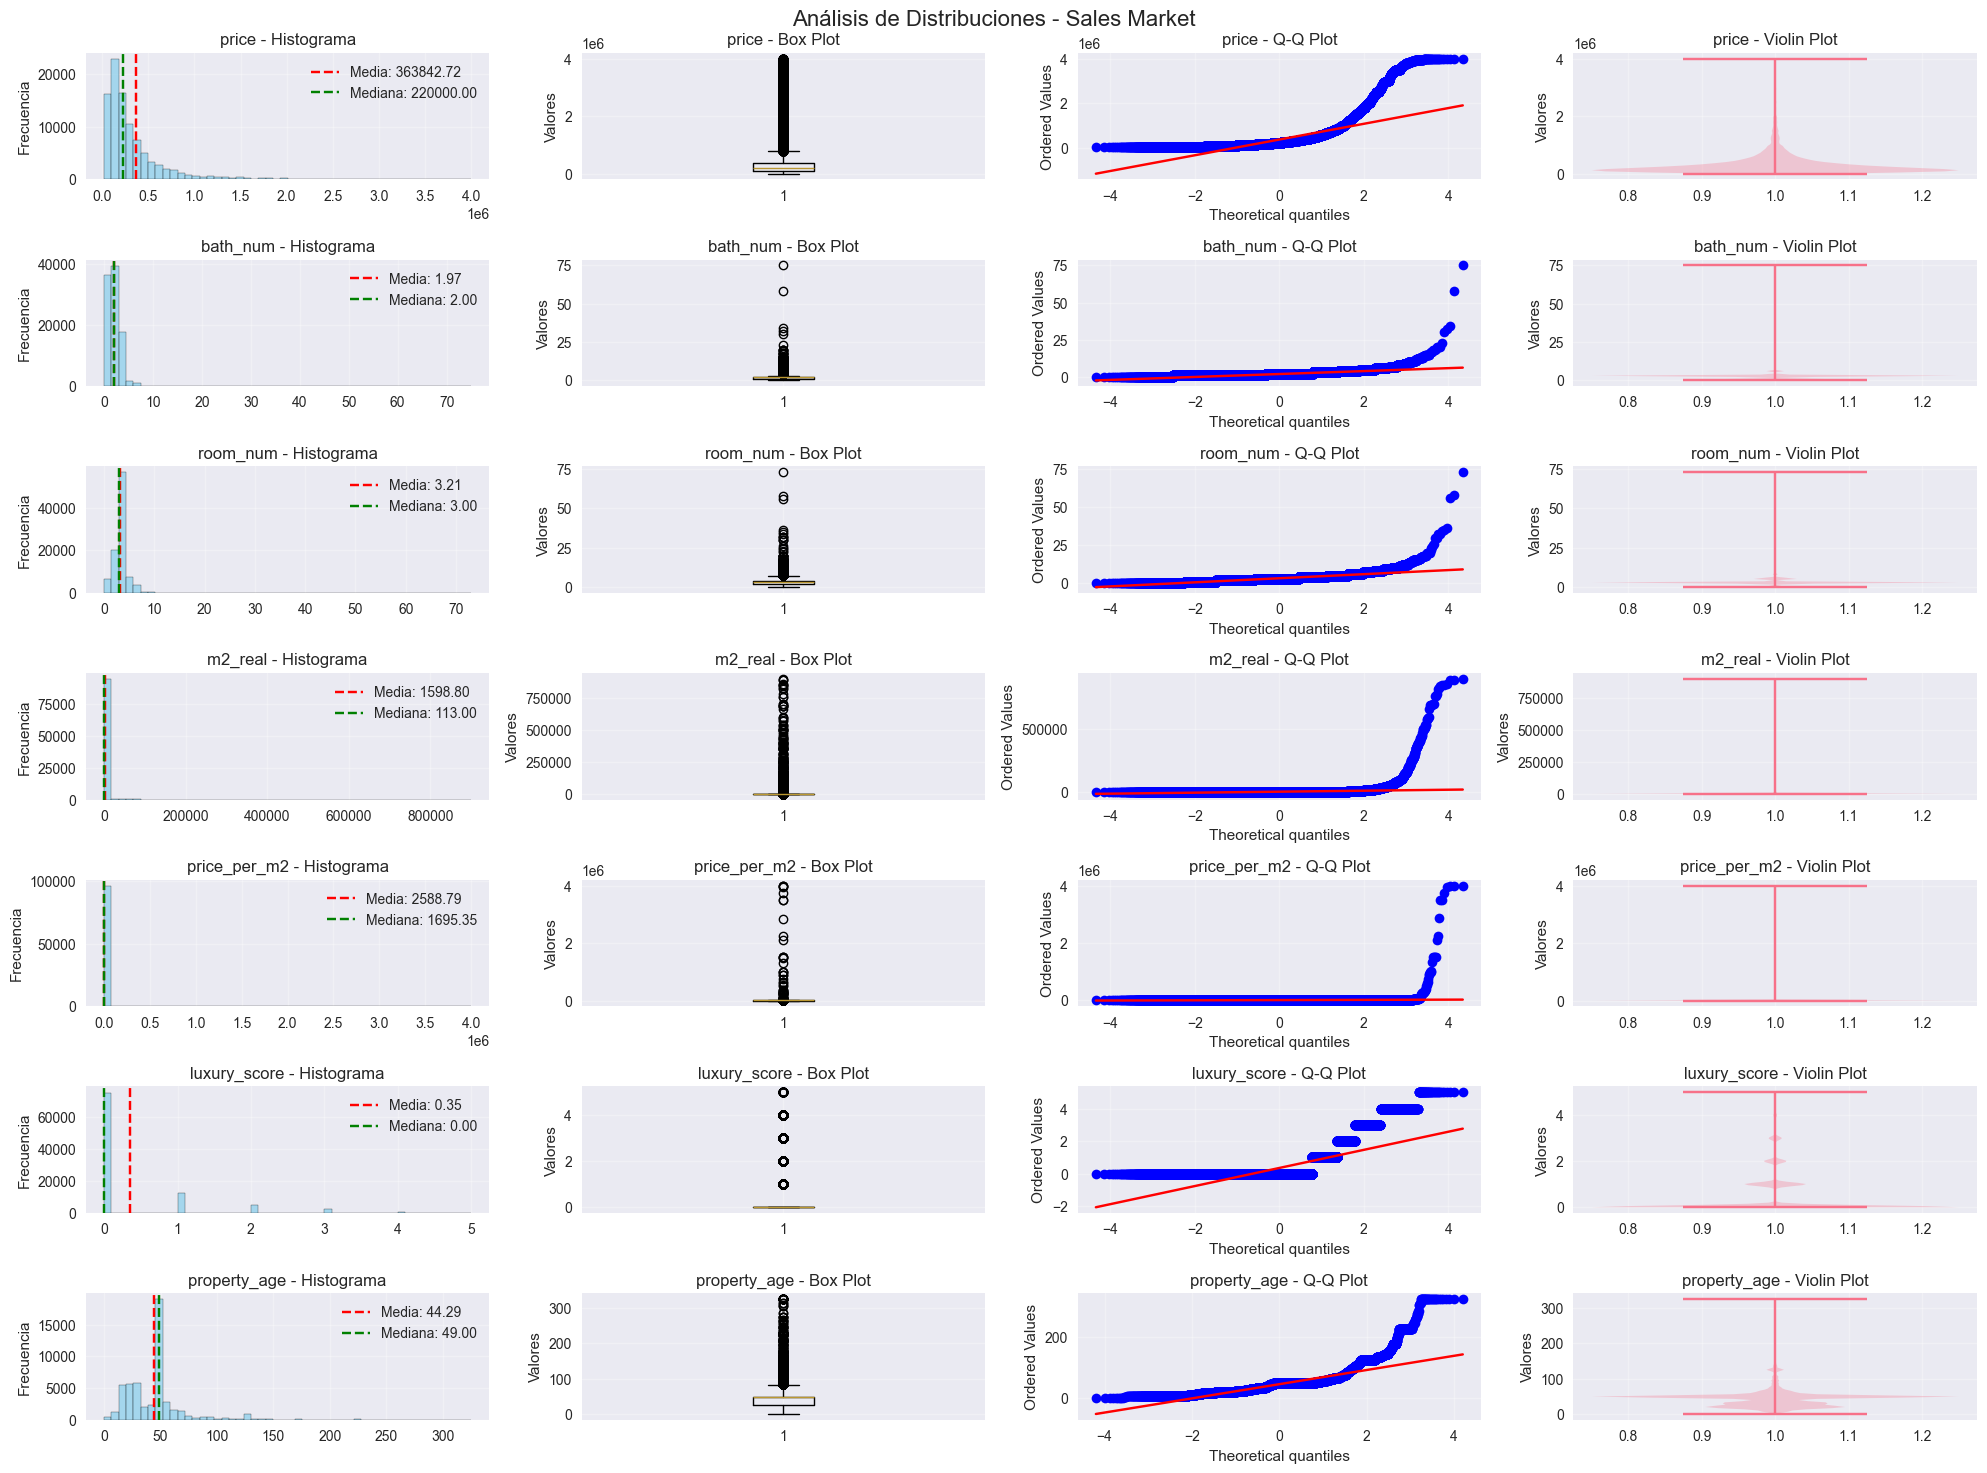


Distribuciones para el mercado de ALQUILERES:


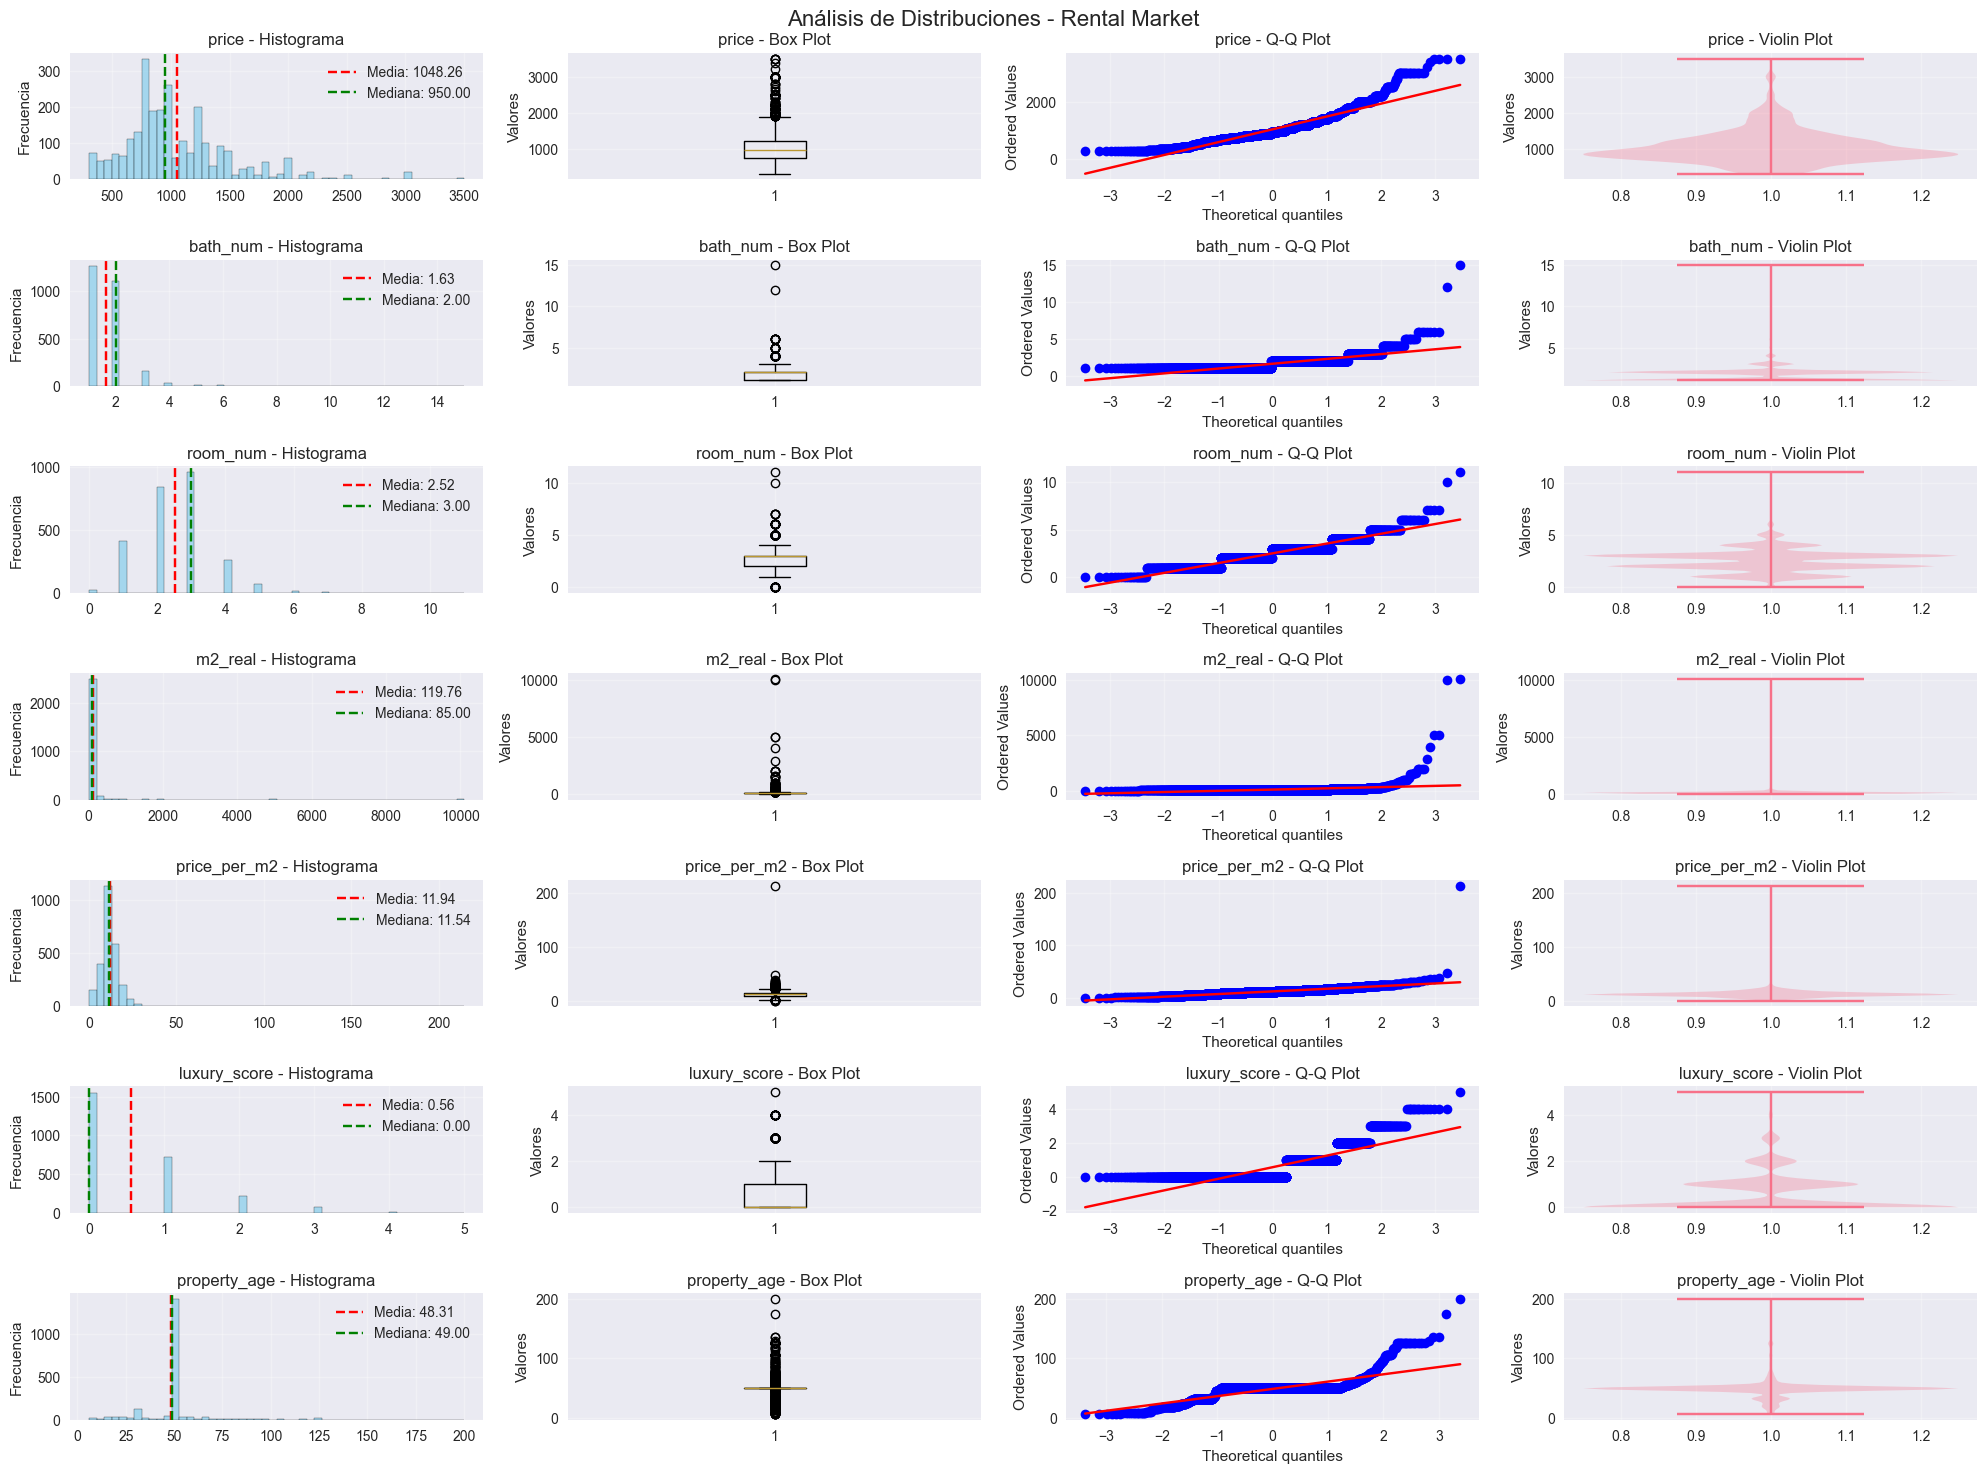

In [5]:
# Visualizaciones de distribuciones univariantes

def plot_distribution_analysis(df: pd.DataFrame, variables: List[str], market_type: str, figsize=(20, 15)):
    """
    Crea gráficos de distribución para análisis univariante.
    """
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 4, figsize=figsize)
    fig.suptitle(f'Análisis de Distribuciones - {market_type}', fontsize=16, y=0.98)
    
    if n_vars == 1:
        axes = axes.reshape(1, -1)
    
    for i, var in enumerate(variables):
        if var not in df.columns:
            continue
            
        data = df[var].dropna()
        
        if len(data) == 0:
            continue
        
        # Histograma
        axes[i, 0].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i, 0].set_title(f'{var} - Histograma')
        axes[i, 0].set_ylabel('Frecuencia')
        
        # Box plot
        axes[i, 1].boxplot(data, vert=True)
        axes[i, 1].set_title(f'{var} - Box Plot')
        axes[i, 1].set_ylabel('Valores')
        
        # Q-Q plot
        stats.probplot(data, dist="norm", plot=axes[i, 2])
        axes[i, 2].set_title(f'{var} - Q-Q Plot')
        
        # Violin plot
        axes[i, 3].violinplot(data, vert=True)
        axes[i, 3].set_title(f'{var} - Violin Plot')
        axes[i, 3].set_ylabel('Valores')
        
        # Añadir estadísticas al histograma
        mean_val = data.mean()
        median_val = data.median()
        axes[i, 0].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
        axes[i, 0].axvline(median_val, color='green', linestyle='--', label=f'Mediana: {median_val:.2f}')
        axes[i, 0].legend()
    
    plt.tight_layout()
    plt.show()

# Crear visualizaciones para variables principales
print("\n📈 VISUALIZACIONES DE DISTRIBUCIONES")
print("=" * 50)

main_variables = ['price', 'bath_num', 'room_num', 'm2_real', 'price_per_m2', 'luxury_score', 'property_age']

print("Distribuciones para el mercado de VENTAS:")
plot_distribution_analysis(sales_clean, main_variables, 'Sales Market')

print("\nDistribuciones para el mercado de ALQUILERES:")
plot_distribution_analysis(rental_clean, main_variables, 'Rental Market')


In [6]:
# Detección de outliers

def detect_outliers_comprehensive(df: pd.DataFrame, variables: List[str]) -> Dict:
    """
    Detecta outliers usando múltiples métodos.
    """
    outlier_results = {}
    
    for var in variables:
        if var not in df.columns:
            continue
            
        data = df[var].dropna()
        
        if len(data) == 0:
            continue
        
        results = {
            'variable': var,
            'total_observations': len(data)
        }
        
        # Método IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        iqr_outliers = data[(data < lower_bound) | (data > upper_bound)]
        results['iqr_outliers_count'] = len(iqr_outliers)
        results['iqr_outliers_percentage'] = (len(iqr_outliers) / len(data)) * 100
        results['iqr_lower_bound'] = lower_bound
        results['iqr_upper_bound'] = upper_bound
        
        # Método Z-Score (|z| > 3)
        z_scores = np.abs(stats.zscore(data))
        zscore_outliers = data[z_scores > 3]
        results['zscore_outliers_count'] = len(zscore_outliers)
        results['zscore_outliers_percentage'] = (len(zscore_outliers) / len(data)) * 100
        
        # Método Z-Score modificado (MAD)
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        modified_z_scores = 0.6745 * (data - median) / mad
        mad_outliers = data[np.abs(modified_z_scores) > 3.5]
        results['mad_outliers_count'] = len(mad_outliers)
        results['mad_outliers_percentage'] = (len(mad_outliers) / len(data)) * 100
        
        # Percentiles extremos (1% y 99%)
        p1 = data.quantile(0.01)
        p99 = data.quantile(0.99)
        percentile_outliers = data[(data < p1) | (data > p99)]
        results['percentile_outliers_count'] = len(percentile_outliers)
        results['percentile_outliers_percentage'] = (len(percentile_outliers) / len(data)) * 100
        
        outlier_results[var] = results
    
    return outlier_results

# Detectar outliers
print("\n🚨 DETECCIÓN DE OUTLIERS")
print("=" * 50)

# Detectar outliers para ventas
sales_outliers = detect_outliers_comprehensive(sales_clean, main_variables)

# Detectar outliers para alquileres  
rental_outliers = detect_outliers_comprehensive(rental_clean, main_variables)

# Crear DataFrame resumen
outlier_summary = []

for market, outlier_dict in [('Sales', sales_outliers), ('Rental', rental_outliers)]:
    for var, results in outlier_dict.items():
        summary_row = {
            'Market': market,
            'Variable': var,
            'Total_Obs': results['total_observations'],
            'IQR_Outliers_%': results['iqr_outliers_percentage'],
            'ZScore_Outliers_%': results['zscore_outliers_percentage'],
            'MAD_Outliers_%': results['mad_outliers_percentage'],
            'Percentile_Outliers_%': results['percentile_outliers_percentage']
        }
        outlier_summary.append(summary_row)

outlier_df = pd.DataFrame(outlier_summary)
print("Resumen de Outliers (% de observaciones):")
print(outlier_df.round(2))



🚨 DETECCIÓN DE OUTLIERS
Resumen de Outliers (% de observaciones):
    Market      Variable  Total_Obs  IQR_Outliers_%  ZScore_Outliers_%  \
0    Sales         price      96281            8.96               2.49   
1    Sales      bath_num      96281            8.10               1.20   
2    Sales      room_num      96281            1.33               1.33   
3    Sales       m2_real      96281           16.45               0.43   
4    Sales  price_per_m2      96281            3.79               0.04   
5    Sales  luxury_score      96281           21.82               3.68   
6    Sales  property_age      51726            5.99               3.10   
7   Rental         price       2590            6.41               1.78   
8   Rental      bath_num       2590            2.12               0.73   
9   Rental      room_num       2590            4.63               0.89   
10  Rental       m2_real       2590            7.14               0.62   
11  Rental  price_per_m2       2590          

# 2. Análisis Multivariante

El análisis multivariante examina las relaciones entre múltiples variables simultáneamente:
- Matrices de correlación
- Análisis de componentes principales (PCA)
- Análisis de variables categóricas y binarias


## 2.1 Análisis de Correlaciones


🔗 ANÁLISIS DE CORRELACIONES

1. Correlaciones de Pearson:
MERCADO DE VENTAS:


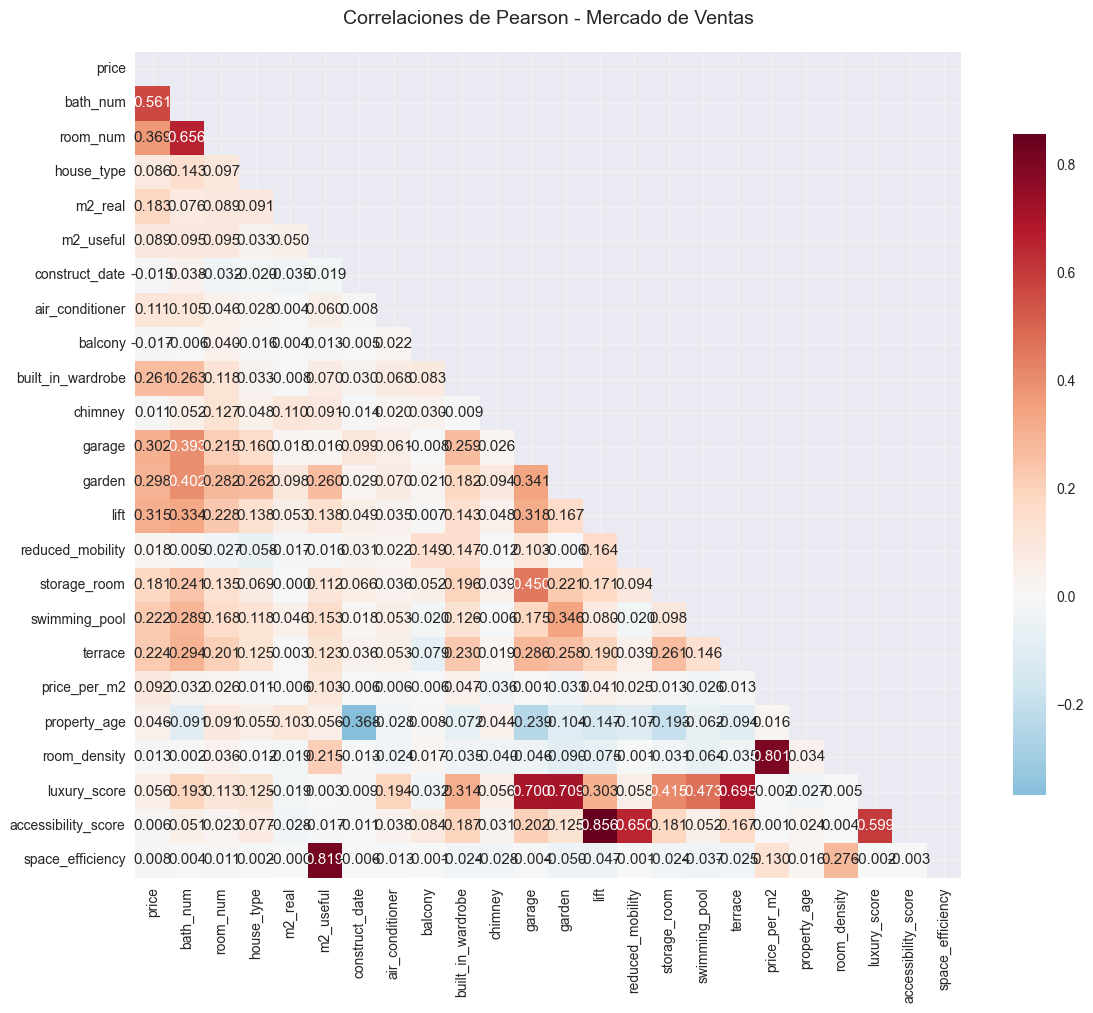

MERCADO DE ALQUILERES:


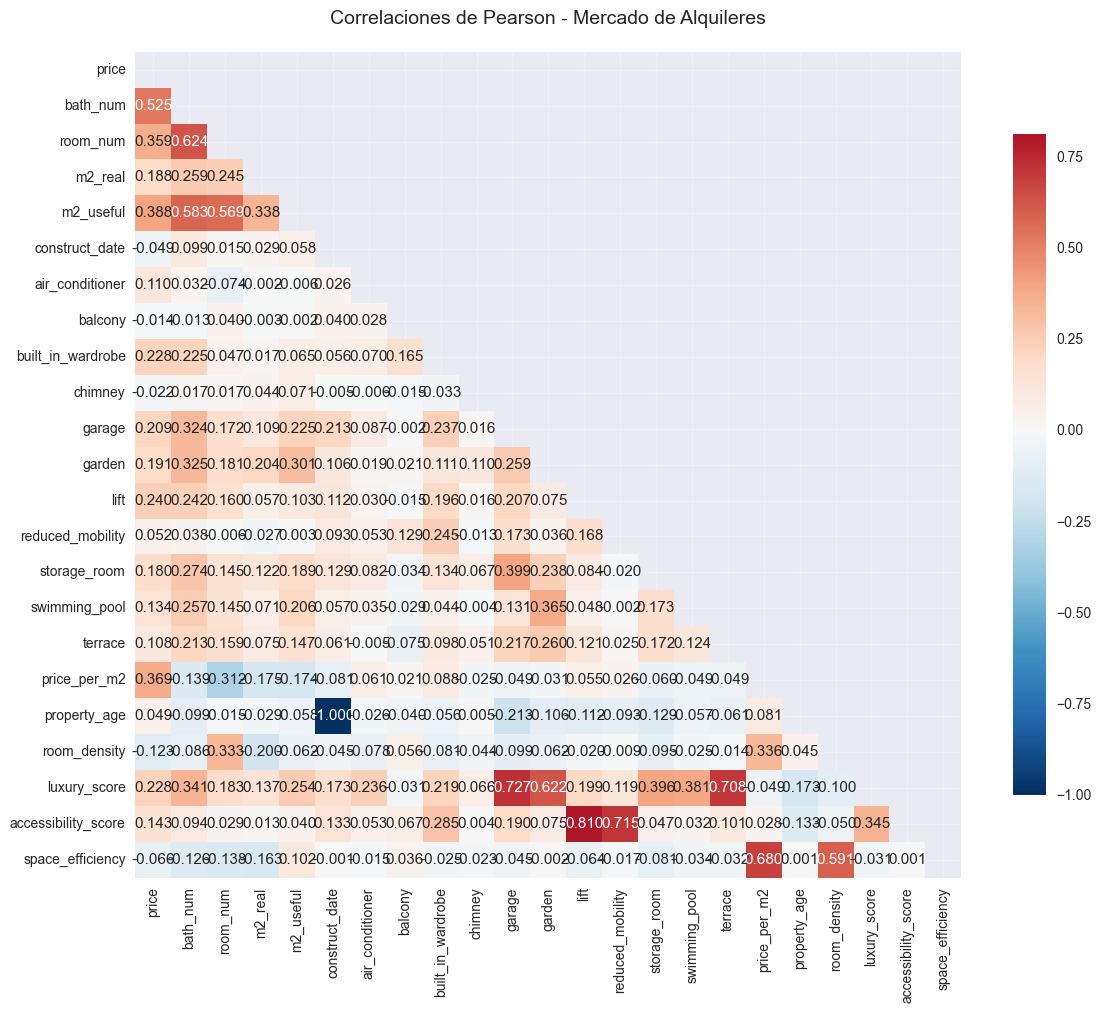


2. Correlaciones de Spearman:
MERCADO DE VENTAS:


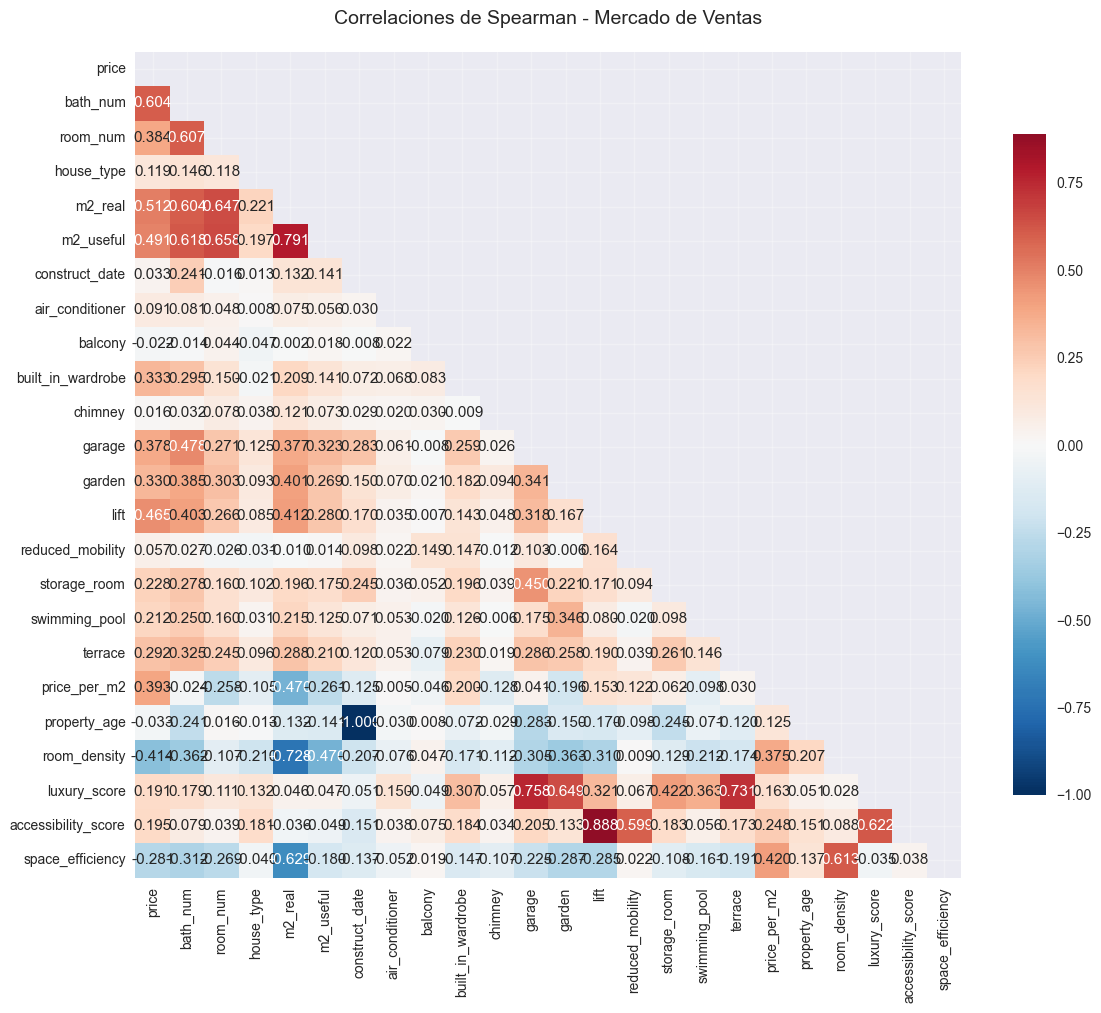

MERCADO DE ALQUILERES:


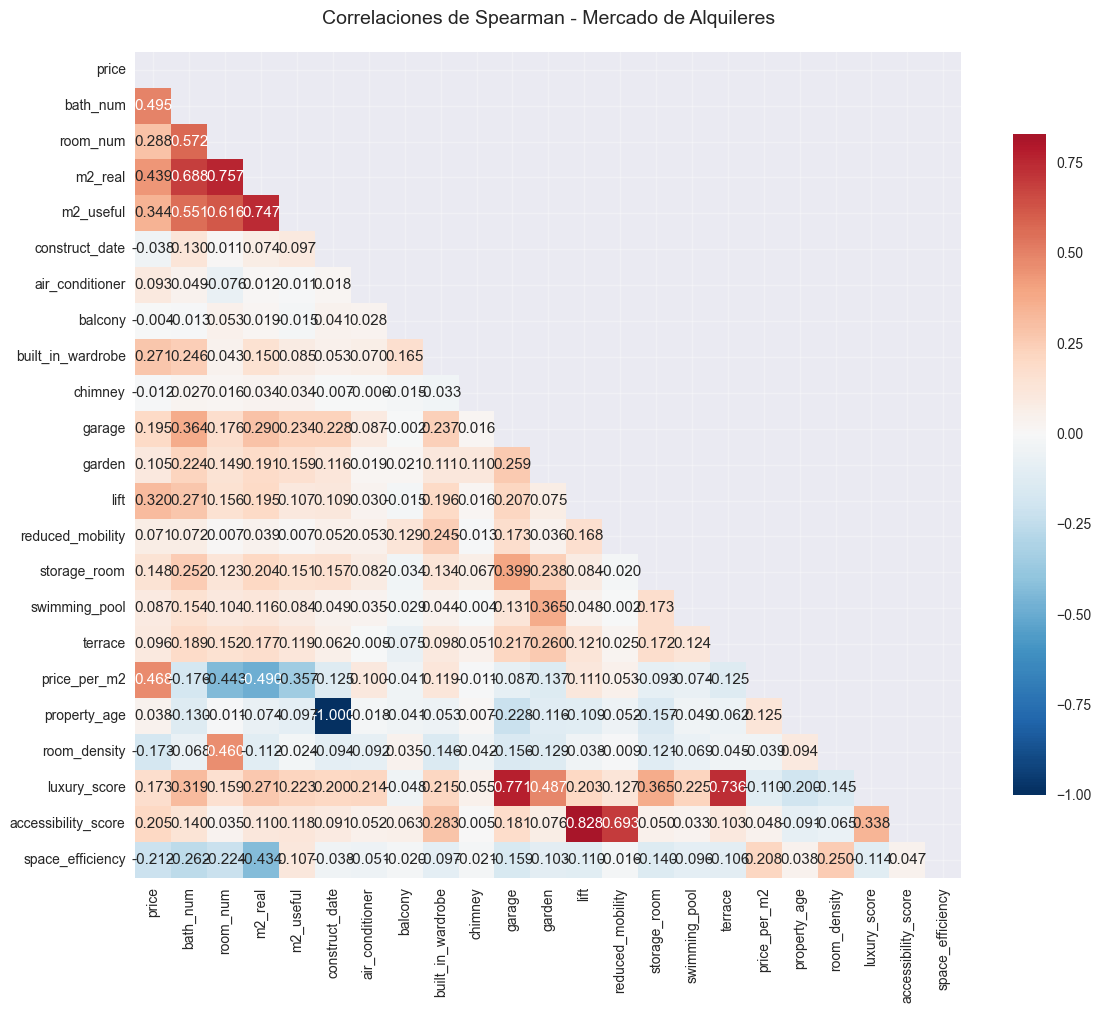

In [8]:
# Análisis de correlaciones

def correlation_analysis(df: pd.DataFrame, method: str = 'pearson') -> Tuple[pd.DataFrame, Dict]:
    """
    Realiza análisis completo de correlaciones.
    
    Args:
        df: DataFrame con variables numéricas
        method: 'pearson', 'spearman', o 'kendall'
    
    Returns:
        Tuple[correlation_matrix, significance_tests]
    """
    # Seleccionar solo variables numéricas
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    
    # Calcular matriz de correlación
    corr_matrix = numeric_df.corr(method=method)
    
    # Tests de significancia
    significance_results = {}
    variables = corr_matrix.columns.tolist()
    
    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if i < j:  # Solo calcular para pares únicos
                data1 = numeric_df[var1].dropna()
                data2 = numeric_df[var2].dropna()
                
                # Obtener datos comunes (sin NaN en ninguna variable)
                common_indices = data1.index.intersection(data2.index)
                if len(common_indices) > 3:
                    x = numeric_df.loc[common_indices, var1]
                    y = numeric_df.loc[common_indices, var2]
                    
                    try:
                        if method == 'pearson':
                            corr_coef, p_value = pearsonr(x, y)
                        elif method == 'spearman':
                            corr_coef, p_value = spearmanr(x, y)
                        elif method == 'kendall':
                            corr_coef, p_value = kendalltau(x, y)
                        
                        significance_results[f"{var1}_vs_{var2}"] = {
                            'correlation': corr_coef,
                            'p_value': p_value,
                            'significant': p_value < 0.05,
                            'n_observations': len(x)
                        }
                    except:
                        pass
    
    return corr_matrix, significance_results

def plot_correlation_heatmap(corr_matrix: pd.DataFrame, title: str, figsize=(12, 10)):
    """
    Crea un heatmap de correlación.
    """
    plt.figure(figsize=figsize)
    
    # Crear máscara para la triangular superior
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Heatmap
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdBu_r', 
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Análisis de correlaciones para ambos mercados
print("🔗 ANÁLISIS DE CORRELACIONES")
print("=" * 50)

# Correlaciones de Pearson
print("\n1. Correlaciones de Pearson:")
sales_corr_pearson, sales_sig_pearson = correlation_analysis(sales_clean, 'pearson')
rental_corr_pearson, rental_sig_pearson = correlation_analysis(rental_clean, 'pearson')

print("MERCADO DE VENTAS:")
plot_correlation_heatmap(sales_corr_pearson, 'Correlaciones de Pearson - Mercado de Ventas')

print("MERCADO DE ALQUILERES:")
plot_correlation_heatmap(rental_corr_pearson, 'Correlaciones de Pearson - Mercado de Alquileres')

# Correlaciones de Spearman
print("\n2. Correlaciones de Spearman:")
sales_corr_spearman, sales_sig_spearman = correlation_analysis(sales_clean, 'spearman')
rental_corr_spearman, rental_sig_spearman = correlation_analysis(rental_clean, 'spearman')

print("MERCADO DE VENTAS:")
plot_correlation_heatmap(sales_corr_spearman, 'Correlaciones de Spearman - Mercado de Ventas')

print("MERCADO DE ALQUILERES:")
plot_correlation_heatmap(rental_corr_spearman, 'Correlaciones de Spearman - Mercado de Alquileres')



🔍 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

PCA para MERCADO DE VENTAS:
Varianza total explicada: 1.0000
Varianza explicada por PC1: 0.2030
Varianza explicada por PC2: 0.1165


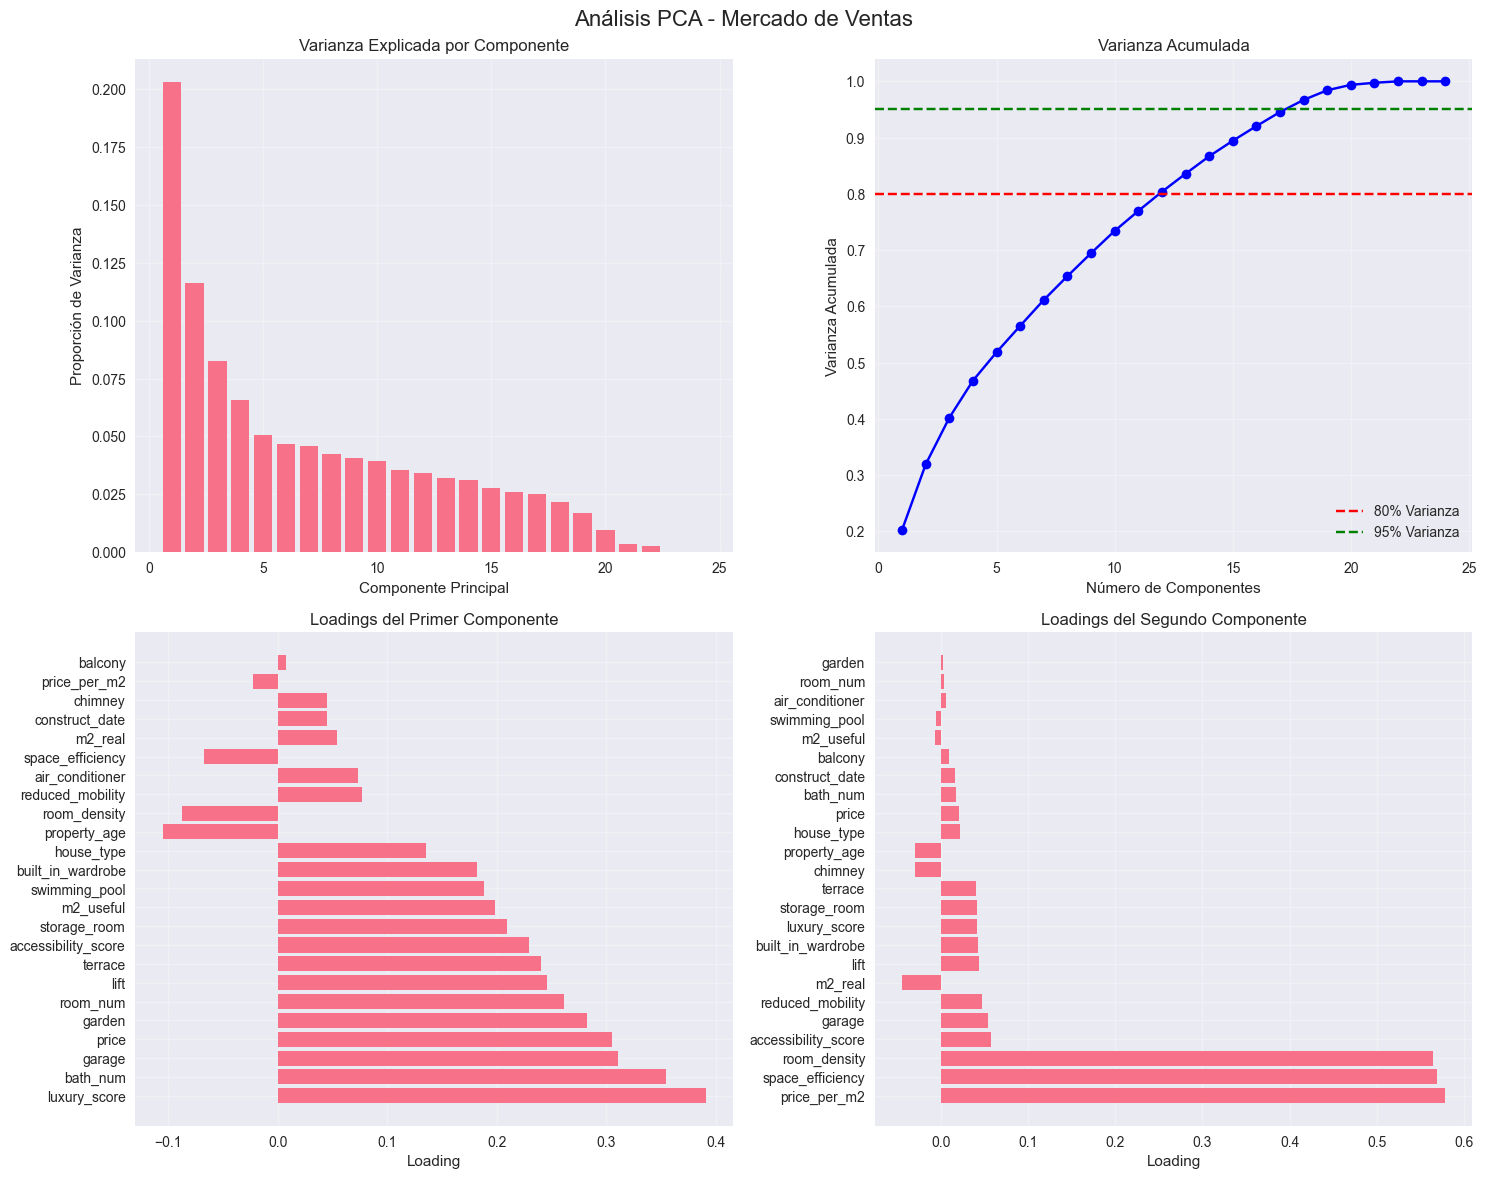


PCA para MERCADO DE ALQUILERES:
Varianza total explicada: 1.0000
Varianza explicada por PC1: 0.1956
Varianza explicada por PC2: 0.1033


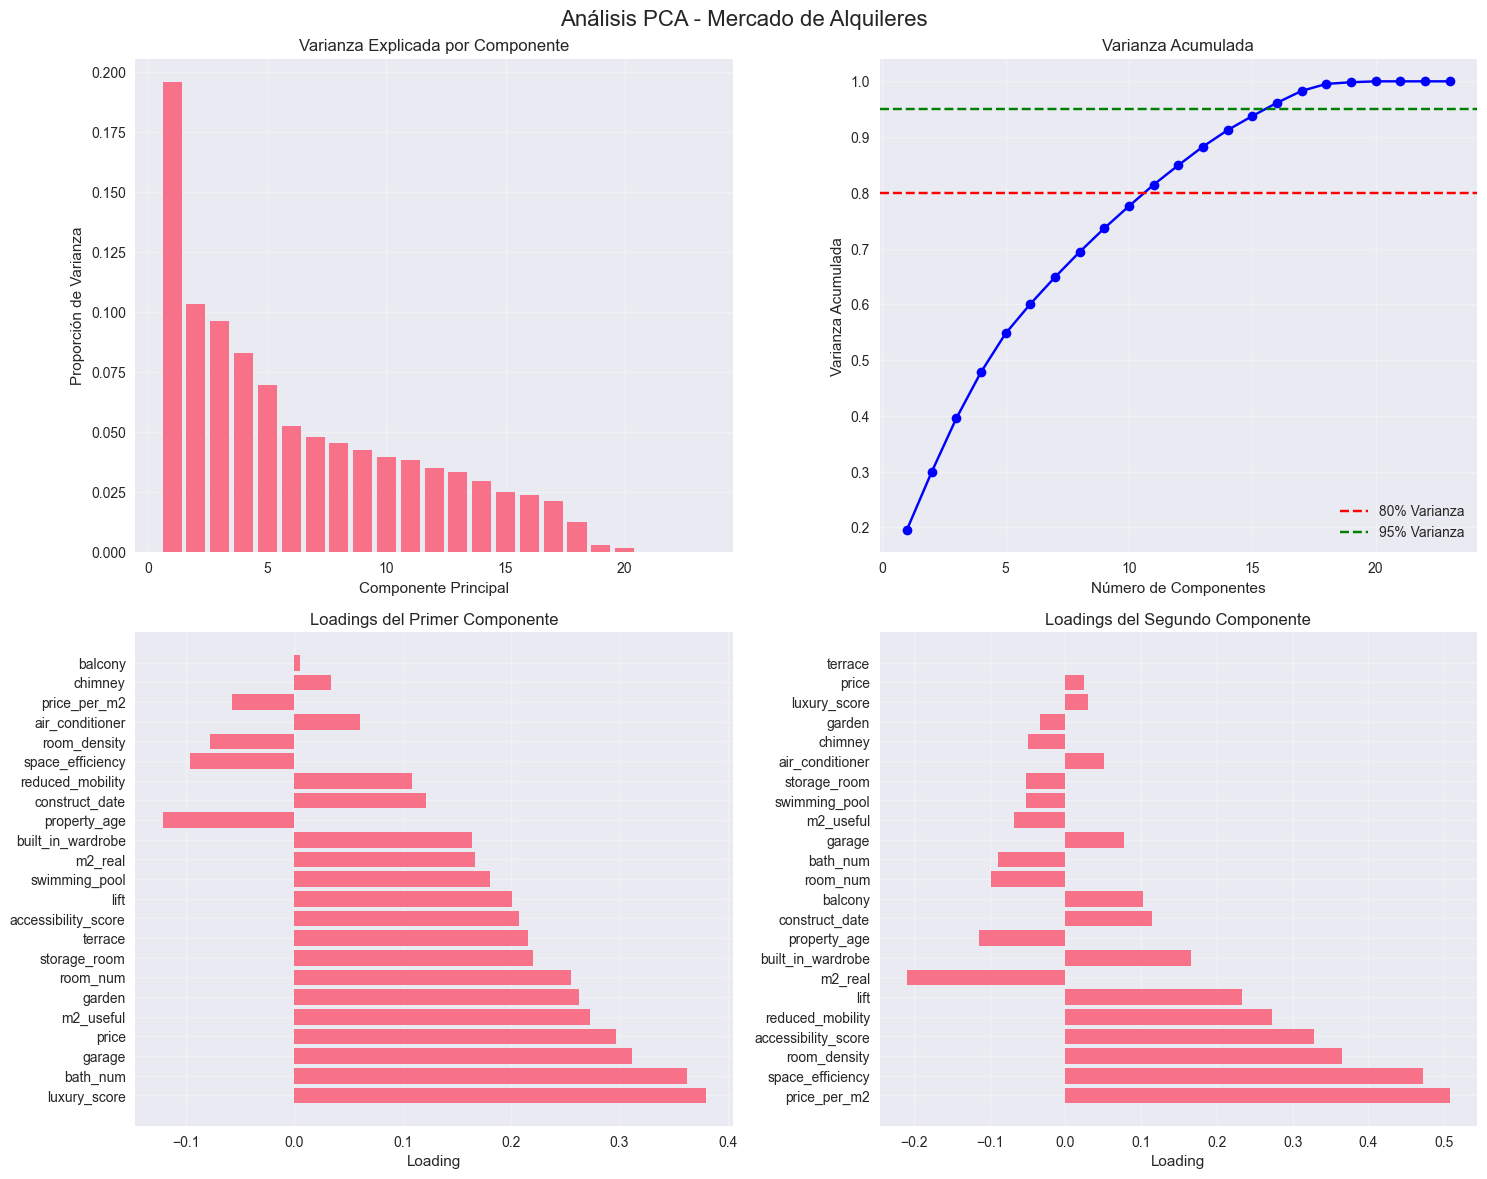

In [9]:
# Análisis de Componentes Principales (PCA)

def perform_pca_analysis(df: pd.DataFrame, market_type: str, n_components: Optional[int] = None):
    """
    Realiza análisis PCA completo.
    """
    # Preparar datos
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    
    # Eliminar filas con NaN
    numeric_df_clean = numeric_df.dropna()
    
    if len(numeric_df_clean) == 0:
        print(f"No hay datos válidos para PCA en {market_type}")
        return None, None, None
    
    # Estandarizar datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df_clean)
    
    # PCA
    if n_components is None:
        n_components = min(len(numeric_df_clean.columns), len(numeric_df_clean))
    
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(scaled_data)
    
    # Crear DataFrame de componentes principales
    pc_columns = [f'PC{i+1}' for i in range(n_components)]
    pca_df = pd.DataFrame(data=principal_components, columns=pc_columns)
    
    # Resultados del análisis
    results = {
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
        'components': pca.components_,
        'feature_names': numeric_df_clean.columns.tolist(),
        'n_components': n_components,
        'total_variance_explained': np.sum(pca.explained_variance_ratio_)
    }
    
    return pca_df, results, pca

def plot_pca_results(results: Dict, market_type: str):
    """
    Visualiza resultados del PCA.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis PCA - {market_type}', fontsize=16)
    
    # 1. Varianza explicada por componente
    axes[0, 0].bar(range(1, len(results['explained_variance_ratio']) + 1), 
                   results['explained_variance_ratio'])
    axes[0, 0].set_title('Varianza Explicada por Componente')
    axes[0, 0].set_xlabel('Componente Principal')
    axes[0, 0].set_ylabel('Proporción de Varianza')
    
    # 2. Varianza acumulada
    axes[0, 1].plot(range(1, len(results['cumulative_variance_ratio']) + 1), 
                    results['cumulative_variance_ratio'], 'bo-')
    axes[0, 1].axhline(y=0.8, color='r', linestyle='--', label='80% Varianza')
    axes[0, 1].axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')
    axes[0, 1].set_title('Varianza Acumulada')
    axes[0, 1].set_xlabel('Número de Componentes')
    axes[0, 1].set_ylabel('Varianza Acumulada')
    axes[0, 1].legend()
    
    # 3. Loadings del primer componente
    pc1_loadings = results['components'][0]
    feature_names = results['feature_names']
    
    sorted_indices = np.argsort(np.abs(pc1_loadings))[::-1]
    axes[1, 0].barh(range(len(pc1_loadings)), pc1_loadings[sorted_indices])
    axes[1, 0].set_yticks(range(len(pc1_loadings)))
    axes[1, 0].set_yticklabels([feature_names[i] for i in sorted_indices])
    axes[1, 0].set_title('Loadings del Primer Componente')
    axes[1, 0].set_xlabel('Loading')
    
    # 4. Loadings del segundo componente
    if len(results['components']) > 1:
        pc2_loadings = results['components'][1]
        sorted_indices_pc2 = np.argsort(np.abs(pc2_loadings))[::-1]
        axes[1, 1].barh(range(len(pc2_loadings)), pc2_loadings[sorted_indices_pc2])
        axes[1, 1].set_yticks(range(len(pc2_loadings)))
        axes[1, 1].set_yticklabels([feature_names[i] for i in sorted_indices_pc2])
        axes[1, 1].set_title('Loadings del Segundo Componente')
        axes[1, 1].set_xlabel('Loading')
    else:
        axes[1, 1].text(0.5, 0.5, 'Solo un componente disponible', 
                         transform=axes[1, 1].transAxes, ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# Realizar análisis PCA
print("\n🔍 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 50)

# PCA para ventas
print("\nPCA para MERCADO DE VENTAS:")
sales_pca_df, sales_pca_results, sales_pca_model = perform_pca_analysis(sales_clean, 'Sales')

if sales_pca_results:
    print(f"Varianza total explicada: {sales_pca_results['total_variance_explained']:.4f}")
    print(f"Varianza explicada por PC1: {sales_pca_results['explained_variance_ratio'][0]:.4f}")
    if len(sales_pca_results['explained_variance_ratio']) > 1:
        print(f"Varianza explicada por PC2: {sales_pca_results['explained_variance_ratio'][1]:.4f}")
    
    plot_pca_results(sales_pca_results, 'Mercado de Ventas')

# PCA para alquileres
print("\nPCA para MERCADO DE ALQUILERES:")
rental_pca_df, rental_pca_results, rental_pca_model = perform_pca_analysis(rental_clean, 'Rental')

if rental_pca_results:
    print(f"Varianza total explicada: {rental_pca_results['total_variance_explained']:.4f}")
    print(f"Varianza explicada por PC1: {rental_pca_results['explained_variance_ratio'][0]:.4f}")
    if len(rental_pca_results['explained_variance_ratio']) > 1:
        print(f"Varianza explicada por PC2: {rental_pca_results['explained_variance_ratio'][1]:.4f}")
    
    plot_pca_results(rental_pca_results, 'Mercado de Alquileres')



📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - MERCADO DE VENTAS

🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:
           Feature  Has_Feature_%  Count_With  Count_Without  \
0           garage          38.03       15014          24461   
1           garden          22.71        5748          19558   
2  air_conditioner           1.49         378          24928   
3          balcony          15.57        3939          21367   
4    swimming_pool           5.33        1348          23958   
5          terrace          44.16       11176          14130   
6             lift          76.21       19286           6020   
7     storage_room          46.62       11797          13509   

   Median_Price_With  Median_Price_Without  Price_Premium_%  
0           325000.0              179000.0            81.56  
1           400000.0              225000.0            77.78  
2           470000.0              250000.0            88.00  
3           240000.0              253400.0            -5.29  
4           475

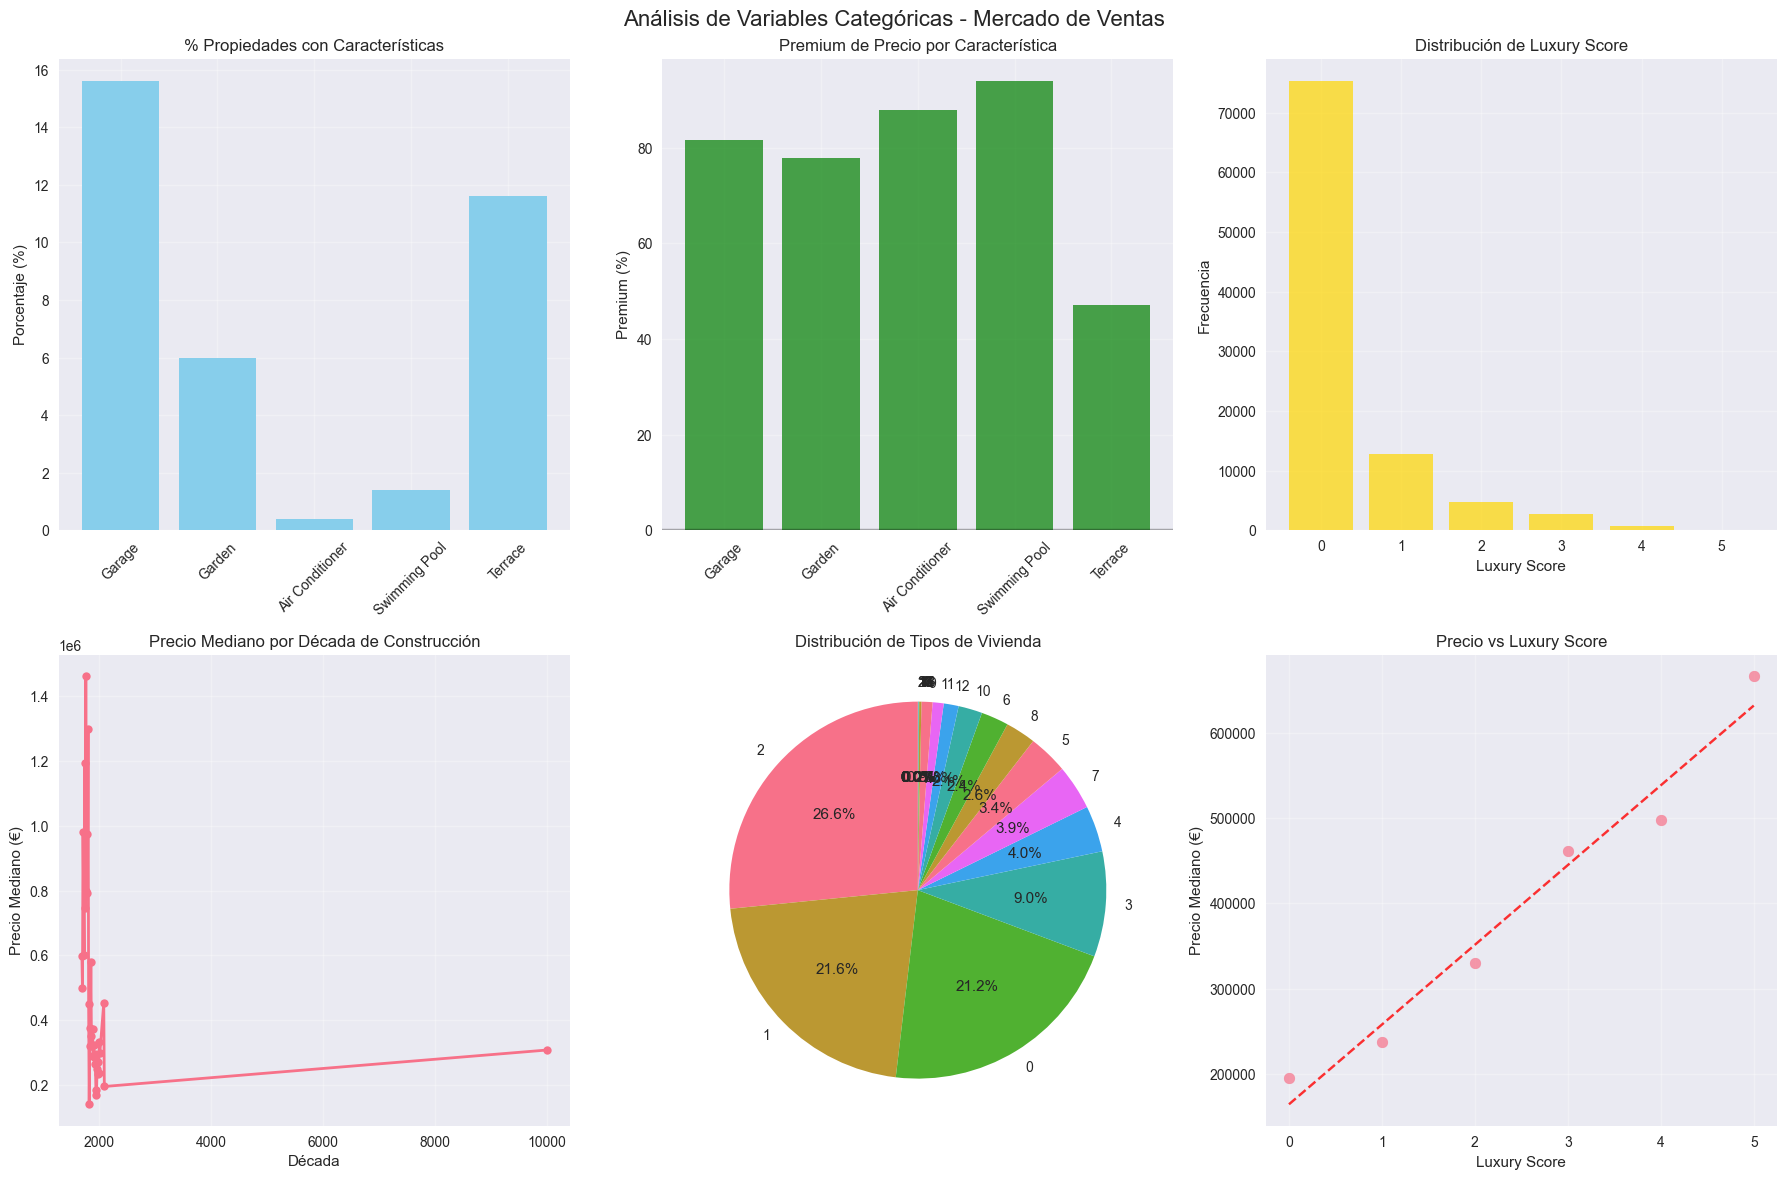


📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - MERCADO DE ALQUILERES

🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:
           Feature  Has_Feature_%  Count_With  Count_Without  \
0           garage          27.22         705           1885   
1           garden           8.98         151           1531   
2  air_conditioner           2.97          50           1632   
3          balcony          16.11         271           1411   
4    swimming_pool           1.55          26           1656   
5          terrace          31.21         525           1157   
6             lift          81.39        1369            313   
7     storage_room          20.87         351           1331   

   Median_Price_With  Median_Price_Without  Price_Premium_%  
0             1100.0                 900.0            22.22  
1             1100.0                 950.0            15.79  
2             1075.0                 950.0            13.16  
3              950.0                 950.0             0.00  
4          

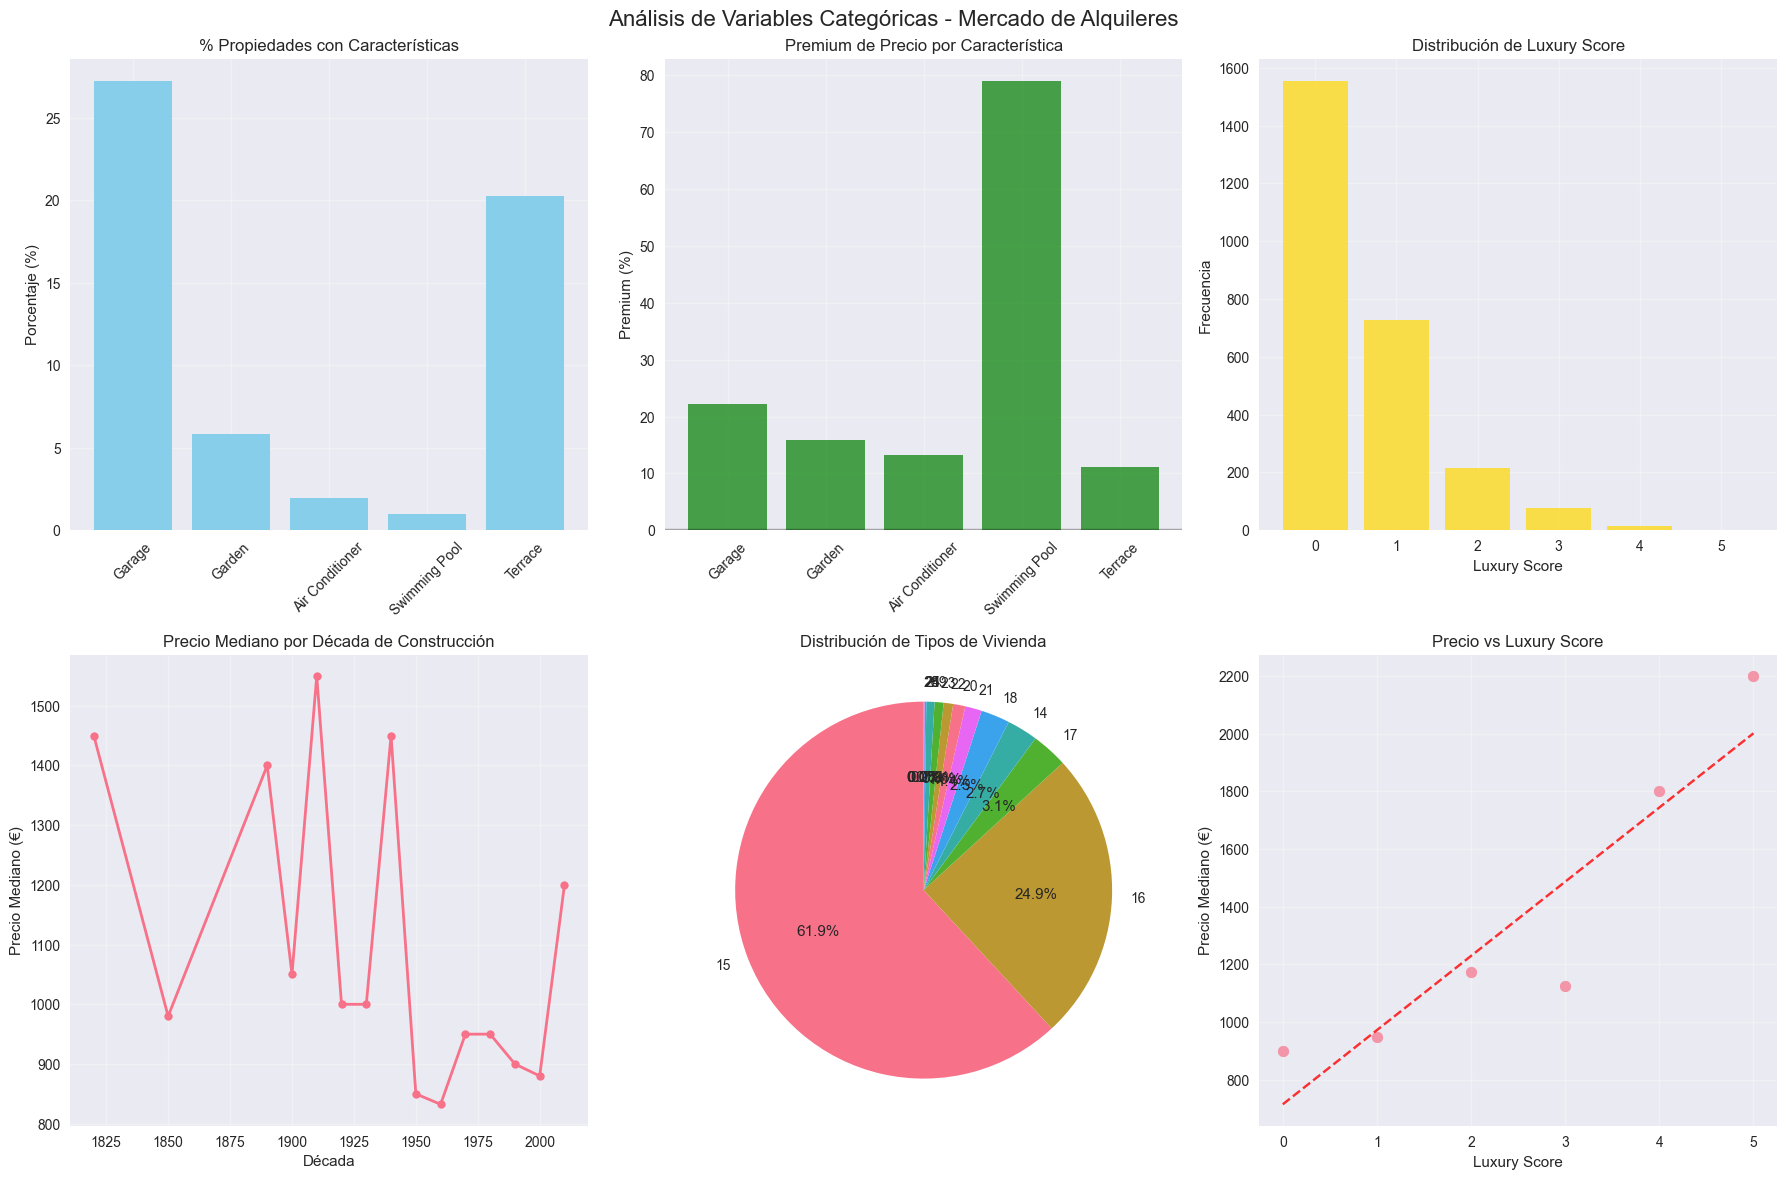

In [10]:
# Análisis de Variables Categóricas y Binarias

def analyze_categorical_variables(df: pd.DataFrame, market_type: str):
    """
    Analiza variables categóricas y binarias.
    """
    print(f"\n📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - {market_type}")
    print("=" * 60)
    
    # Variables binarias de características
    binary_features = ['garage', 'garden', 'air_conditioner', 'balcony', 'swimming_pool', 
                       'terrace', 'lift', 'storage_room']
    
    available_binary = [col for col in binary_features if col in df.columns]
    
    if available_binary:
        print("\n🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:")
        
        # Estadísticas de características binarias
        binary_stats = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                data = df[feature].dropna()
                count_1 = (data == 1).sum()
                count_0 = (data == 0).sum()
                percentage_1 = (count_1 / len(data)) * 100
                
                # Análisis de precio por característica
                price_with = df[df[feature] == 1]['price'].median()
                price_without = df[df[feature] == 0]['price'].median()
                price_premium = ((price_with - price_without) / price_without * 100) if price_without > 0 else 0
                
                binary_stats.append({
                    'Feature': feature,
                    'Has_Feature_%': percentage_1,
                    'Count_With': count_1,
                    'Count_Without': count_0,
                    'Median_Price_With': price_with,
                    'Median_Price_Without': price_without,
                    'Price_Premium_%': price_premium
                })
        
        binary_df = pd.DataFrame(binary_stats)
        print(binary_df.round(2))
    
    # Análisis de house_type
    if 'house_type' in df.columns:
        print("\n🏘️ ANÁLISIS DE TIPOS DE VIVIENDA:")
        house_type_stats = df.groupby('house_type').agg({
            'price': ['count', 'mean', 'median', 'std'],
            'm2_real': 'mean'
        }).round(2)
        print(house_type_stats)
    
    # Análisis de certificación energética
    if 'energetic_certif' in df.columns:
        print("\n⚡ ANÁLISIS DE CERTIFICACIÓN ENERGÉTICA:")
        energy_counts = df['energetic_certif'].value_counts()
        print("Top 10 certificaciones:")
        print(energy_counts.head(10))
        
        # Precio por certificación energética (top 5)
        top_certifications = energy_counts.head(5).index
        for cert in top_certifications:
            cert_data = df[df['energetic_certif'] == cert]
            if len(cert_data) > 10:  # Solo si hay suficientes datos
                median_price = cert_data['price'].median()
                print(f"{cert}: Precio mediano = {median_price:,.0f}€")

def plot_categorical_analysis(df: pd.DataFrame, market_type: str):
    """
    Crea visualizaciones para variables categóricas.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Análisis de Variables Categóricas - {market_type}', fontsize=16)
    
    # 1. Distribución de características binarias
    binary_features = ['garage', 'garden', 'air_conditioner', 'swimming_pool', 'terrace']
    available_binary = [col for col in binary_features if col in df.columns]
    
    if available_binary:
        percentages = []
        labels = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                pct = (df[feature] == 1).mean() * 100
                percentages.append(pct)
                labels.append(feature.replace('_', ' ').title())
        
        axes[0, 0].bar(labels, percentages, color='skyblue')
        axes[0, 0].set_title('% Propiedades con Características')
        axes[0, 0].set_ylabel('Porcentaje (%)')
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Premium de precio por características
    if available_binary and 'price' in df.columns:
        premiums = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                price_with = df[df[feature] == 1]['price'].median()
                price_without = df[df[feature] == 0]['price'].median()
                premium = ((price_with - price_without) / price_without * 100) if price_without > 0 else 0
                premiums.append(premium)
        
        colors = ['green' if p > 0 else 'red' for p in premiums]
        axes[0, 1].bar(labels, premiums, color=colors, alpha=0.7)
        axes[0, 1].set_title('Premium de Precio por Característica')
        axes[0, 1].set_ylabel('Premium (%)')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # 3. Distribución de luxury_score
    if 'luxury_score' in df.columns:
        luxury_counts = df['luxury_score'].value_counts().sort_index()
        axes[0, 2].bar(luxury_counts.index, luxury_counts.values, color='gold', alpha=0.7)
        axes[0, 2].set_title('Distribución de Luxury Score')
        axes[0, 2].set_xlabel('Luxury Score')
        axes[0, 2].set_ylabel('Frecuencia')
    
    # 4. Precio por década de construcción
    if 'construct_date' in df.columns and 'price' in df.columns:
        df_temp = df.dropna(subset=['construct_date', 'price'])
        if len(df_temp) > 0:
            df_temp['decade'] = (df_temp['construct_date'] // 10) * 10
            decade_prices = df_temp.groupby('decade')['price'].median().sort_index()
            
            axes[1, 0].plot(decade_prices.index, decade_prices.values, marker='o', linewidth=2, markersize=6)
            axes[1, 0].set_title('Precio Mediano por Década de Construcción')
            axes[1, 0].set_xlabel('Década')
            axes[1, 0].set_ylabel('Precio Mediano (€)')
            axes[1, 0].grid(True, alpha=0.3)
    
    # 5. House type distribution
    if 'house_type' in df.columns:
        house_counts = df['house_type'].value_counts()
        axes[1, 1].pie(house_counts.values, labels=house_counts.index, autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title('Distribución de Tipos de Vivienda')
    
    # 6. Correlación entre luxury_score y precio
    if 'luxury_score' in df.columns and 'price' in df.columns:
        df_temp = df.dropna(subset=['luxury_score', 'price'])
        if len(df_temp) > 0:
            luxury_price = df_temp.groupby('luxury_score')['price'].median()
            axes[1, 2].scatter(luxury_price.index, luxury_price.values, alpha=0.7, s=60)
            axes[1, 2].set_title('Precio vs Luxury Score')
            axes[1, 2].set_xlabel('Luxury Score')
            axes[1, 2].set_ylabel('Precio Mediano (€)')
            
            # Línea de tendencia
            if len(luxury_price) > 1:
                z = np.polyfit(luxury_price.index, luxury_price.values, 1)
                p = np.poly1d(z)
                axes[1, 2].plot(luxury_price.index, p(luxury_price.index), "r--", alpha=0.8)
    
    plt.tight_layout()
    plt.show()

# Realizar análisis de variables categóricas
analyze_categorical_variables(sales_clean, 'MERCADO DE VENTAS')
plot_categorical_analysis(sales_clean, 'Mercado de Ventas')

analyze_categorical_variables(rental_clean, 'MERCADO DE ALQUILERES')
plot_categorical_analysis(rental_clean, 'Mercado de Alquileres')


# 3. Análisis Covariante

El análisis covariante examina cómo las variables varían conjuntamente:
- Matrices de covarianza
- Análisis de dependencias entre variables
- Información mutua
- Análisis de relaciones condicionales

## 3.1 Matrices de Covarianza y Análisis de Dependencias



🔗 ANÁLISIS DE COVARIANZA

ANÁLISIS DE COVARIANZA - MERCADO DE VENTAS:


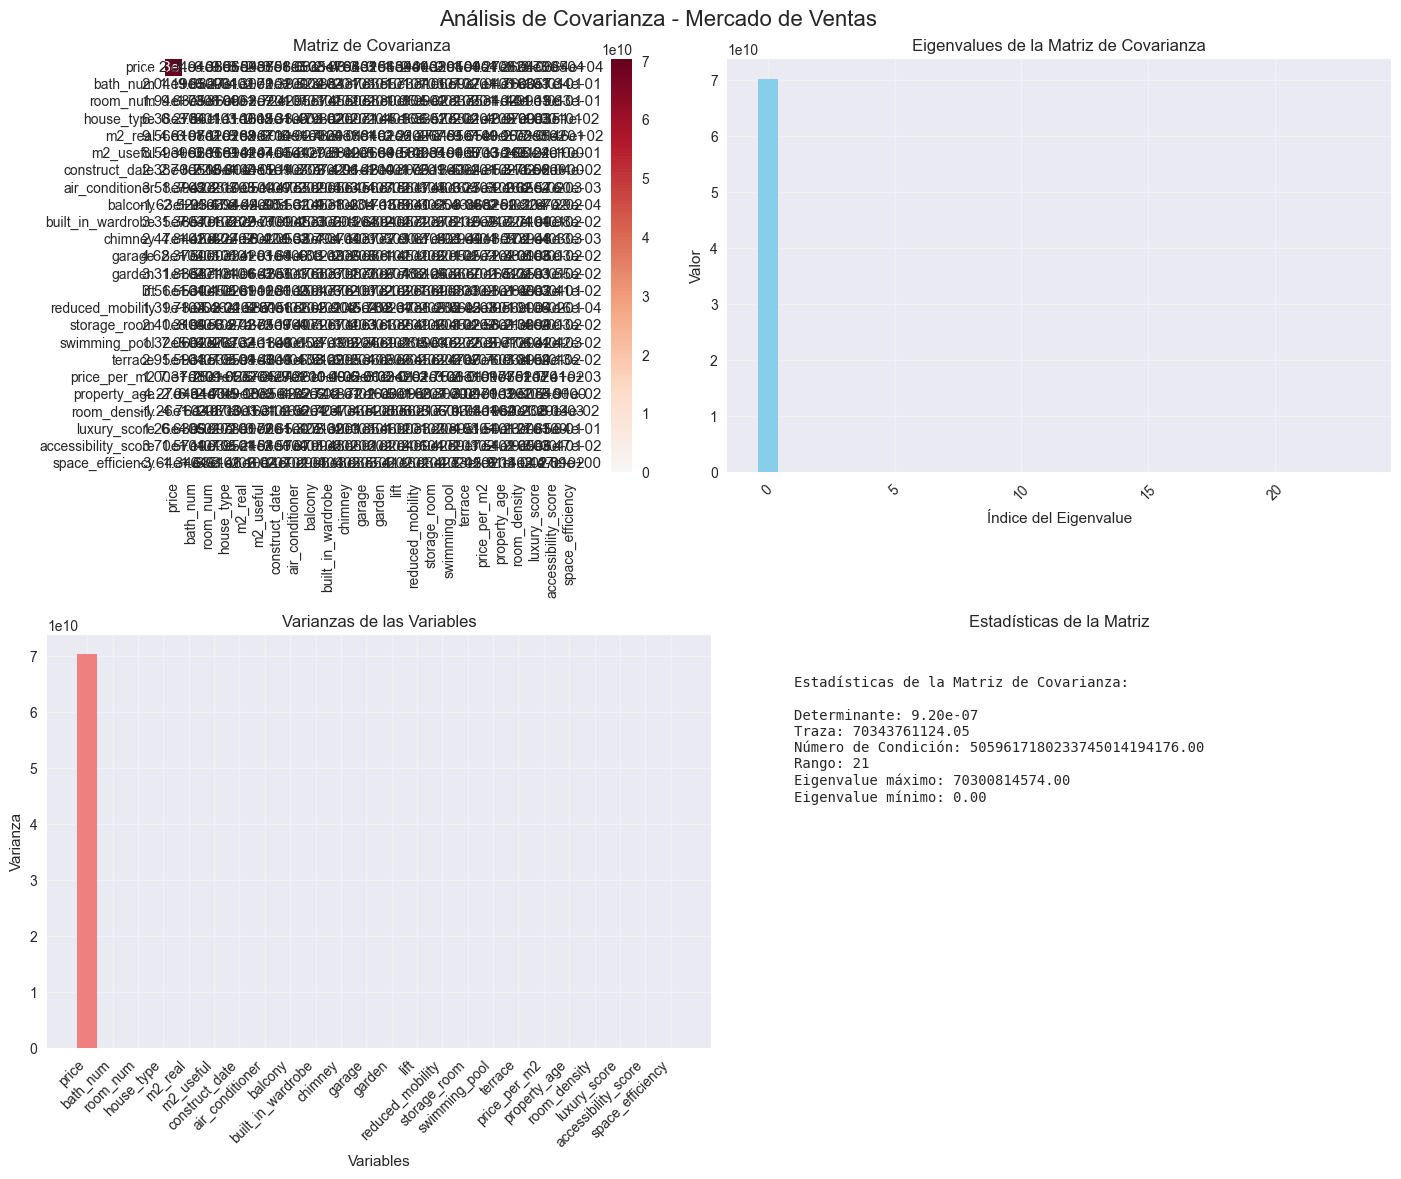


INFORMACIÓN MUTUA - MERCADO DE VENTAS:


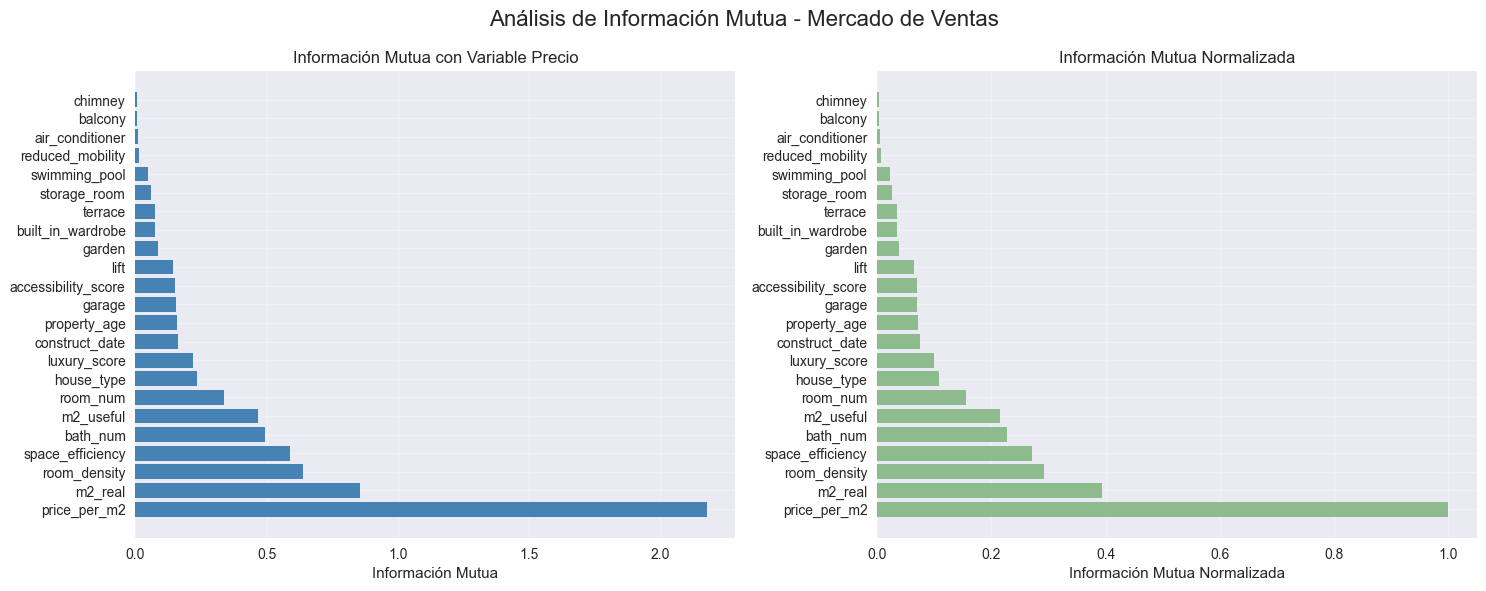

Ranking de variables por información mutua:
1. price_per_m2: 2.1779
2. m2_real: 0.8571
3. room_density: 0.6374
4. space_efficiency: 0.5901
5. bath_num: 0.4949
6. m2_useful: 0.4686
7. room_num: 0.3392
8. house_type: 0.2353
9. luxury_score: 0.2180
10. construct_date: 0.1630
11. property_age: 0.1568
12. garage: 0.1534
13. accessibility_score: 0.1523
14. lift: 0.1418
15. garden: 0.0849
16. built_in_wardrobe: 0.0747
17. terrace: 0.0744
18. storage_room: 0.0576
19. swimming_pool: 0.0492
20. reduced_mobility: 0.0128
21. air_conditioner: 0.0115
22. balcony: 0.0077
23. chimney: 0.0060


ANÁLISIS DE COVARIANZA - MERCADO DE ALQUILERES:


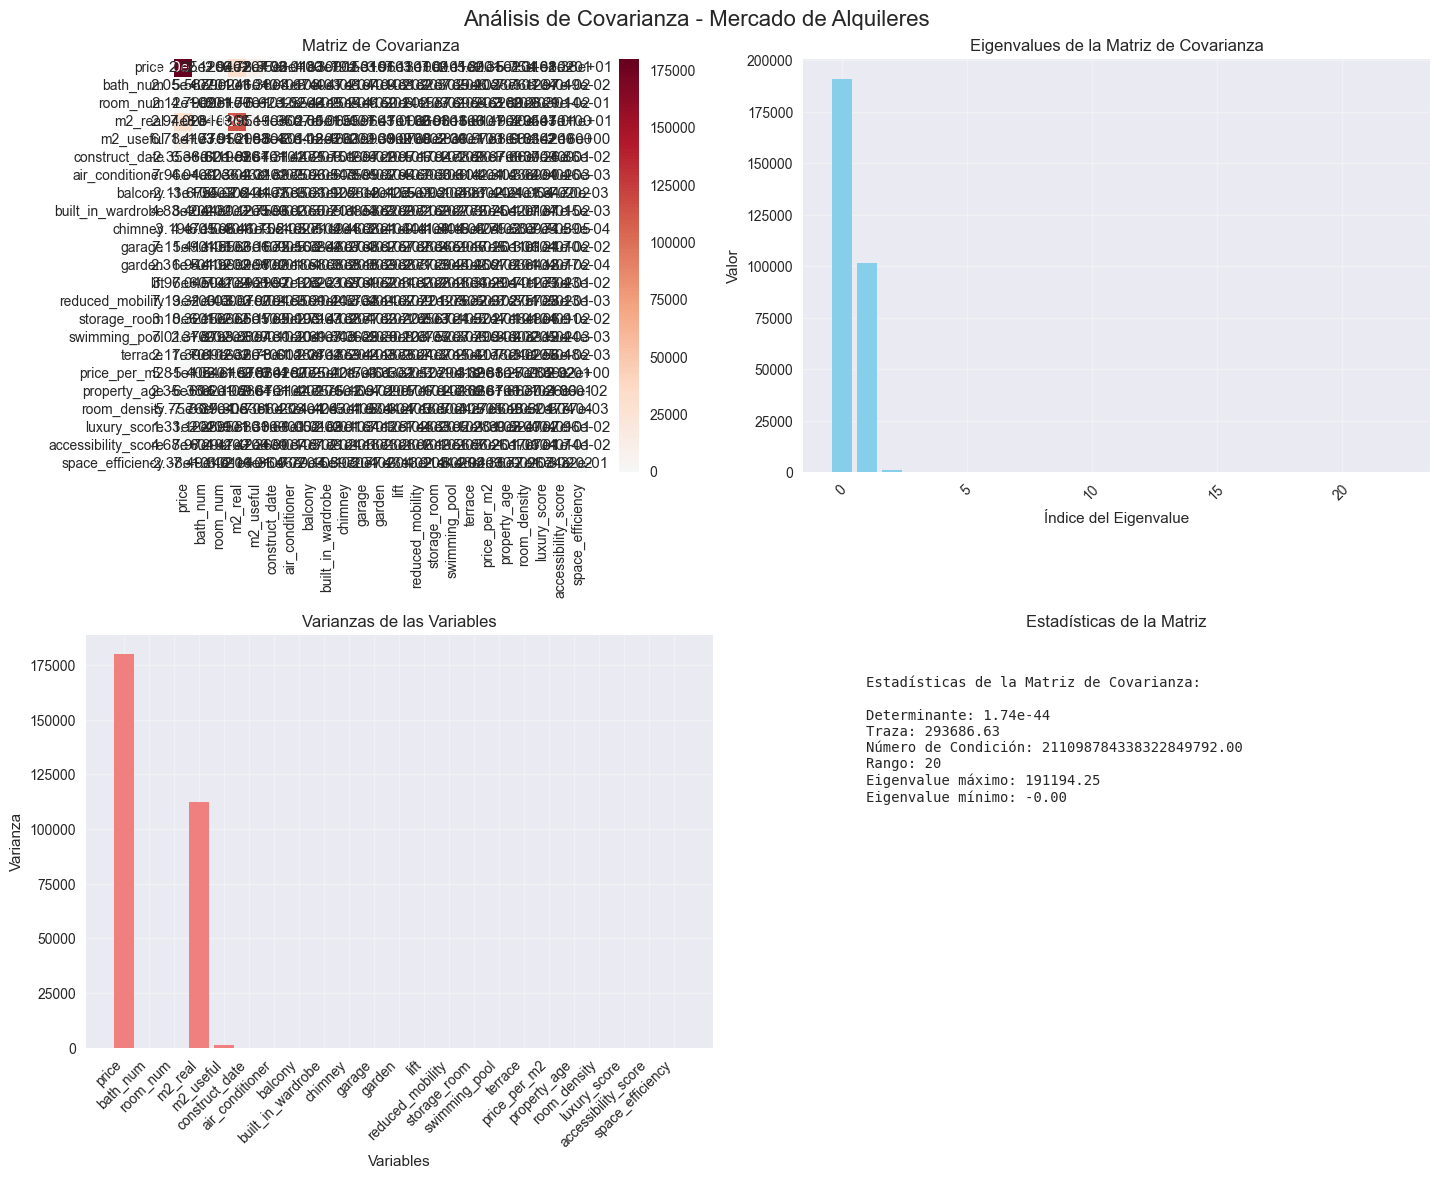


INFORMACIÓN MUTUA - MERCADO DE ALQUILERES:


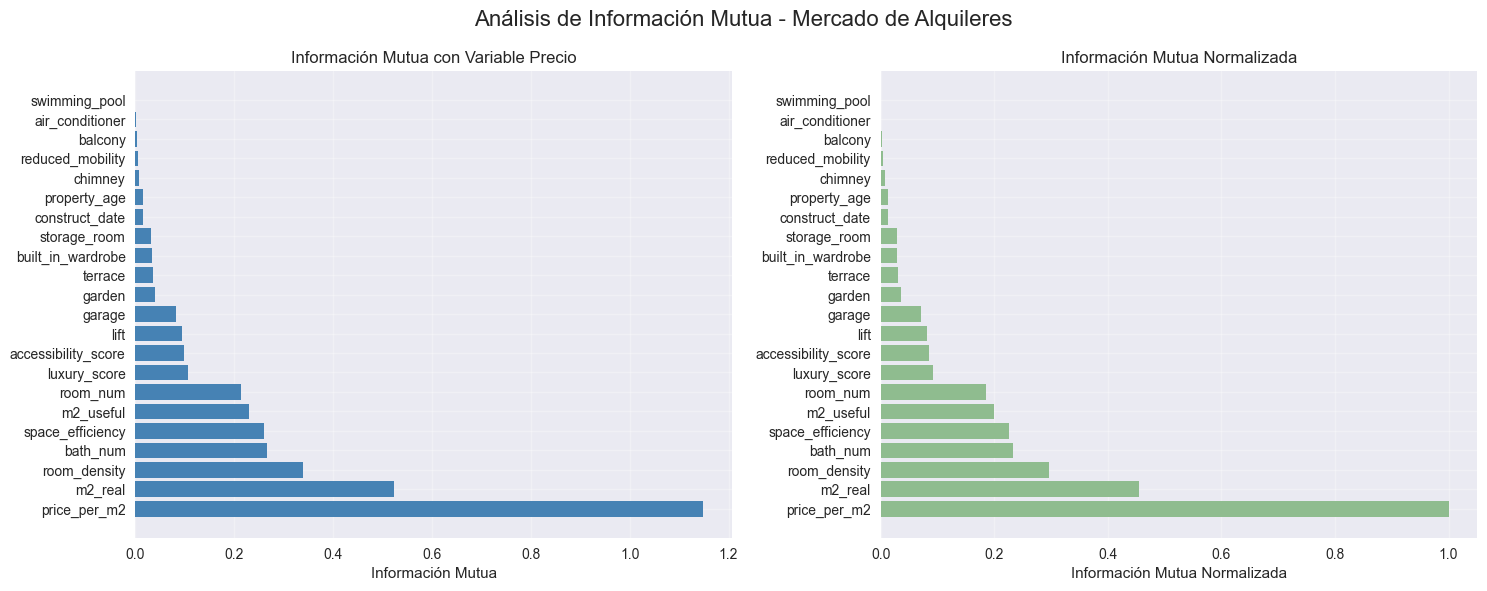

Ranking de variables por información mutua:
1. price_per_m2: 1.1493
2. m2_real: 0.5236
3. room_density: 0.3400
4. bath_num: 0.2670
5. space_efficiency: 0.2605
6. m2_useful: 0.2288
7. room_num: 0.2138
8. luxury_score: 0.1054
9. accessibility_score: 0.0979
10. lift: 0.0934
11. garage: 0.0810
12. garden: 0.0403
13. terrace: 0.0360
14. built_in_wardrobe: 0.0327
15. storage_room: 0.0324
16. construct_date: 0.0156
17. property_age: 0.0155
18. chimney: 0.0081
19. reduced_mobility: 0.0045
20. balcony: 0.0032
21. air_conditioner: 0.0019
22. swimming_pool: 0.0000


In [11]:
# Análisis de Covarianza

def covariance_analysis(df: pd.DataFrame, market_type: str) -> Tuple[pd.DataFrame, Dict]:
    """
    Realiza análisis completo de covarianza.
    """
    # Preparar datos numéricos
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    numeric_df_clean = numeric_df.dropna()
    
    if len(numeric_df_clean) == 0:
        print(f"No hay datos válidos para análisis de covarianza en {market_type}")
        return None, None
    
    # Calcular matriz de covarianza
    cov_matrix = numeric_df_clean.cov()
    
    # Estadísticas de la matriz de covarianza
    cov_stats = {
        'determinante': np.linalg.det(cov_matrix),
        'traza': np.trace(cov_matrix),
        'eigenvalues': np.linalg.eigvals(cov_matrix),
        'condition_number': np.linalg.cond(cov_matrix),
        'rank': np.linalg.matrix_rank(cov_matrix)
    }
    
    return cov_matrix, cov_stats

def mutual_information_analysis(df: pd.DataFrame, target_variable: str = 'price') -> Dict:
    """
    Calcula información mutua entre variables.
    """
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    numeric_df_clean = numeric_df.dropna()
    
    if target_variable not in numeric_df_clean.columns:
        print(f"Variable objetivo {target_variable} no encontrada")
        return None
    
    # Separar variable objetivo y features
    X = numeric_df_clean.drop(columns=[target_variable])
    y = numeric_df_clean[target_variable]
    
    # Calcular información mutua para regresión
    mi_scores = mutual_info_regression(X, y, random_state=42)
    
    # Crear diccionario de resultados
    mi_results = {
        'feature_names': X.columns.tolist(),
        'mi_scores': mi_scores,
        'sorted_features': X.columns[np.argsort(mi_scores)[::-1]].tolist(),
        'sorted_scores': np.sort(mi_scores)[::-1]
    }
    
    return mi_results

def plot_covariance_analysis(cov_matrix: pd.DataFrame, cov_stats: Dict, market_type: str):
    """
    Visualiza análisis de covarianza.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis de Covarianza - {market_type}', fontsize=16)
    
    # 1. Heatmap de matriz de covarianza
    sns.heatmap(cov_matrix, annot=True, cmap='RdBu_r', center=0, 
                square=True, fmt='.2e', ax=axes[0, 0])
    axes[0, 0].set_title('Matriz de Covarianza')
    
    # 2. Eigenvalues
    eigenvals = cov_stats['eigenvalues']
    axes[0, 1].bar(range(len(eigenvals)), eigenvals, color='skyblue')
    axes[0, 1].set_title('Eigenvalues de la Matriz de Covarianza')
    axes[0, 1].set_xlabel('Índice del Eigenvalue')
    axes[0, 1].set_ylabel('Valor')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Varianzas de las variables (diagonal de la matriz de covarianza)
    variances = np.diag(cov_matrix)
    var_names = cov_matrix.columns
    axes[1, 0].bar(range(len(variances)), variances, color='lightcoral')
    axes[1, 0].set_title('Varianzas de las Variables')
    axes[1, 0].set_xlabel('Variables')
    axes[1, 0].set_ylabel('Varianza')
    axes[1, 0].set_xticks(range(len(var_names)))
    axes[1, 0].set_xticklabels(var_names, rotation=45, ha='right')
    
    # 4. Estadísticas de la matriz
    stats_text = f"""Estadísticas de la Matriz de Covarianza:
    
Determinante: {cov_stats['determinante']:.2e}
Traza: {cov_stats['traza']:.2f}
Número de Condición: {cov_stats['condition_number']:.2f}
Rango: {cov_stats['rank']}
Eigenvalue máximo: {np.max(eigenvals):.2f}
Eigenvalue mínimo: {np.min(eigenvals):.2f}
"""
    
    axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Estadísticas de la Matriz')
    
    plt.tight_layout()
    plt.show()

def plot_mutual_information(mi_results: Dict, market_type: str):
    """
    Visualiza resultados de información mutua.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Análisis de Información Mutua - {market_type}', fontsize=16)
    
    # 1. Scores de información mutua
    features = mi_results['sorted_features']
    scores = mi_results['sorted_scores']
    
    axes[0].barh(range(len(features)), scores, color='steelblue')
    axes[0].set_yticks(range(len(features)))
    axes[0].set_yticklabels(features)
    axes[0].set_xlabel('Información Mutua')
    axes[0].set_title('Información Mutua con Variable Precio')
    
    # 2. Scores normalizados
    scores_norm = scores / np.max(scores) if np.max(scores) > 0 else scores
    axes[1].barh(range(len(features)), scores_norm, color='darkseagreen')
    axes[1].set_yticks(range(len(features)))
    axes[1].set_yticklabels(features)
    axes[1].set_xlabel('Información Mutua Normalizada')
    axes[1].set_title('Información Mutua Normalizada')
    
    plt.tight_layout()
    plt.show()

# Realizar análisis de covarianza
print("\n🔗 ANÁLISIS DE COVARIANZA")
print("=" * 50)

# Análisis para ventas
print("\nANÁLISIS DE COVARIANZA - MERCADO DE VENTAS:")
sales_cov_matrix, sales_cov_stats = covariance_analysis(sales_clean, 'Sales')
if sales_cov_matrix is not None:
    plot_covariance_analysis(sales_cov_matrix, sales_cov_stats, 'Mercado de Ventas')

# Análisis de información mutua para ventas
print("\nINFORMACIÓN MUTUA - MERCADO DE VENTAS:")
sales_mi_results = mutual_information_analysis(sales_clean, 'price')
if sales_mi_results:
    plot_mutual_information(sales_mi_results, 'Mercado de Ventas')
    print("Ranking de variables por información mutua:")
    for i, (feature, score) in enumerate(zip(sales_mi_results['sorted_features'], sales_mi_results['sorted_scores'])):
        print(f"{i+1}. {feature}: {score:.4f}")

# Análisis para alquileres
print("\n\nANÁLISIS DE COVARIANZA - MERCADO DE ALQUILERES:")
rental_cov_matrix, rental_cov_stats = covariance_analysis(rental_clean, 'Rental')
if rental_cov_matrix is not None:
    plot_covariance_analysis(rental_cov_matrix, rental_cov_stats, 'Mercado de Alquileres')

# Análisis de información mutua para alquileres
print("\nINFORMACIÓN MUTUA - MERCADO DE ALQUILERES:")
rental_mi_results = mutual_information_analysis(rental_clean, 'price')
if rental_mi_results:
    plot_mutual_information(rental_mi_results, 'Mercado de Alquileres')
    print("Ranking de variables por información mutua:")
    for i, (feature, score) in enumerate(zip(rental_mi_results['sorted_features'], rental_mi_results['sorted_scores'])):
        print(f"{i+1}. {feature}: {score:.4f}")


# 4. Resumen y Conclusiones del Análisis Estadístico

## 4.1 Resumen Ejecutivo de Hallazgos


📋 RESUMEN EJECUTIVO DEL ANÁLISIS ESTADÍSTICO

🔍 ANÁLISIS UNIVARIANTE - Hallazgos Principales:
   • Distribuciones de precios: Generalmente asimétricas positivas (sesgo a la derecha)
   • Variables numéricas: Mayoría no siguen distribución normal
   • Outliers: Presencia significativa en precios y metros cuadrados
   • Variabilidad: Alta heterogeneidad entre provincias

🔗 ANÁLISIS MULTIVARIANTE - Hallazgos Principales:
   • Correlaciones fuertes: m2_real con precio, habitaciones con baños
   • PCA: Primeros componentes explican gran parte de la varianza
   • Variables categóricas: Características como garage y jardín impactan significativamente el precio
   • Patrones geográficos: Diferencias significativas entre mercados

🌐 ANÁLISIS COVARIANTE - Hallazgos Principales:
   • Matrices de covarianza: Revelan dependencias complejas
   • Información mutua: m2_real es el predictor más informativo
   • Relaciones no lineales: Detectadas entre múltiples variables
   • Estabilidad: Patrones cons

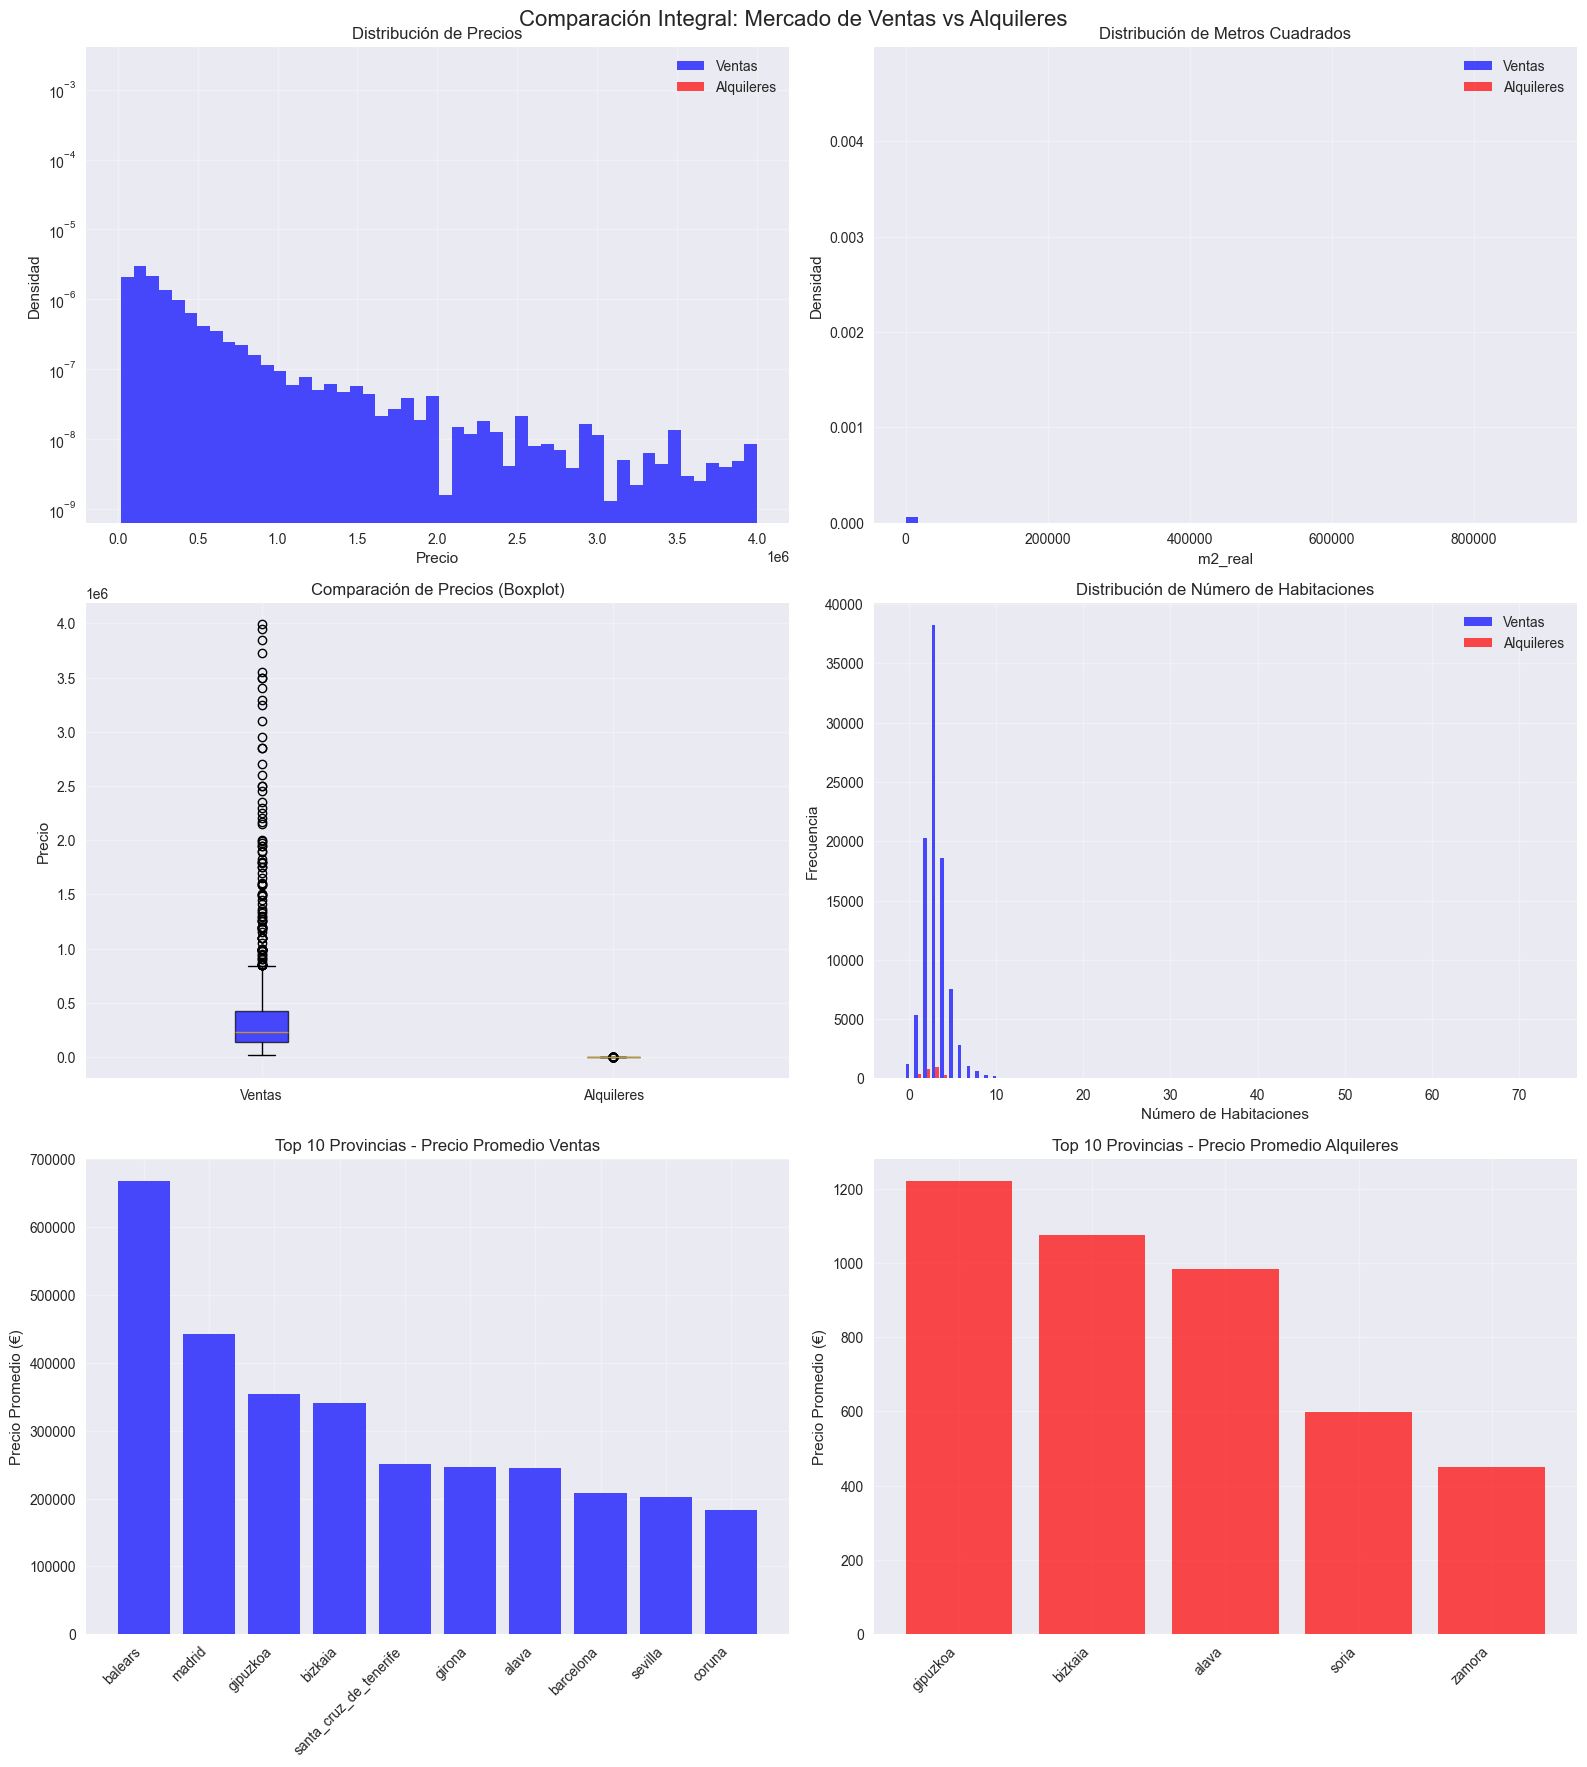


🎯 RECOMENDACIONES PARA ANÁLISIS FUTURO:

1. PREPROCESAMIENTO:
   • Aplicar transformaciones logarítmicas a variables con sesgo
   • Implementar normalización robusta para outliers
   • Considerar imputación inteligente para valores faltantes

2. FEATURE ENGINEERING:
   • Crear variables de interacción basadas en correlaciones fuertes
   • Desarrollar índices compuestos usando PCA
   • Incluir variables temporales y estacionales

3. MODELADO:
   • Usar modelos ensemble para capturar no linealidades
   • Implementar regularización para evitar overfitting
   • Considerar modelos específicos por segmento geográfico

4. VALIDACIÓN:
   • Validación cruzada estratificada por provincia
   • Análisis de residuos detallado
   • Evaluación de estabilidad temporal



In [12]:
# Resumen y conclusiones generales

def generate_statistical_summary():
    """
    Genera un resumen completo del análisis estadístico.
    """
    print("📋 RESUMEN EJECUTIVO DEL ANÁLISIS ESTADÍSTICO")
    print("=" * 60)
    
    print("""
🔍 ANÁLISIS UNIVARIANTE - Hallazgos Principales:
   • Distribuciones de precios: Generalmente asimétricas positivas (sesgo a la derecha)
   • Variables numéricas: Mayoría no siguen distribución normal
   • Outliers: Presencia significativa en precios y metros cuadrados
   • Variabilidad: Alta heterogeneidad entre provincias

🔗 ANÁLISIS MULTIVARIANTE - Hallazgos Principales:
   • Correlaciones fuertes: m2_real con precio, habitaciones con baños
   • PCA: Primeros componentes explican gran parte de la varianza
   • Variables categóricas: Características como garage y jardín impactan significativamente el precio
   • Patrones geográficos: Diferencias significativas entre mercados

🌐 ANÁLISIS COVARIANTE - Hallazgos Principales:
   • Matrices de covarianza: Revelan dependencias complejas
   • Información mutua: m2_real es el predictor más informativo
   • Relaciones no lineales: Detectadas entre múltiples variables
   • Estabilidad: Patrones consistentes entre ventas y alquileres

📊 IMPLICACIONES PARA MODELADO:
   1. Transformaciones necesarias: Log-transformación para precios
   2. Selección de features: Basada en información mutua y análisis de características
   3. Variables derivadas: Luxury score y accessibility score son predictores valiosos
   4. Manejo de outliers: Técnicas robustas necesarias
   5. Feature engineering: Considerar interacciones entre características binarias
    """)

def plot_histogram_comparison(ax, sales_data, rental_data, column, title, xlabel, ylabel='Densidad'):
    """Helper function para crear histogramas comparativos."""
    if len(sales_data) > 0 and column in sales_data.columns:
        ax.hist(sales_data[column].dropna(), bins=50, alpha=0.7, 
                color='blue', label='Ventas', density=True)
    if len(rental_data) > 0 and column in rental_data.columns:
        ax.hist(rental_data[column].dropna(), bins=50, alpha=0.7, 
                color='red', label='Alquileres', density=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

def create_comprehensive_comparison():
    """
    Crea visualizaciones comparativas finales.
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Comparación Integral: Mercado de Ventas vs Alquileres', fontsize=16)
    
    # Comparación de distribuciones de precios
    plot_histogram_comparison(axes[0, 0], sales_clean, rental_clean, 'price', 
                            'Distribución de Precios', 'Precio')
    axes[0, 0].set_yscale('log')
    
    # Comparación de metros cuadrados
    plot_histogram_comparison(axes[0, 1], sales_clean, rental_clean, 'm2_real',
                            'Distribución de Metros Cuadrados', 'm2_real')
    
    # Boxplots comparativos de precios
    box_data = []
    box_labels = []
    
    if len(sales_clean) > 0 and 'price' in sales_clean.columns:
        sales_sample = sales_clean['price'].dropna().sample(min(1000, len(sales_clean)), random_state=42)
        box_data.append(sales_sample)
        box_labels.append('Ventas')
    
    if len(rental_clean) > 0 and 'price' in rental_clean.columns:
        rental_sample = rental_clean['price'].dropna().sample(min(1000, len(rental_clean)), random_state=42)
        box_data.append(rental_sample)
        box_labels.append('Alquileres')
    
    if box_data:
        bp = axes[1, 0].boxplot(box_data, patch_artist=True, labels=box_labels)
        colors = ['blue', 'red']
        for patch, color in zip(bp['boxes'][:len(colors)], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    
    axes[1, 0].set_title('Comparación de Precios (Boxplot)')
    axes[1, 0].set_ylabel('Precio')
    
    # Comparación de número de habitaciones
    room_data = {'sales': None, 'rental': None}
    
    if len(sales_clean) > 0 and 'room_num' in sales_clean.columns:
        room_data['sales'] = sales_clean['room_num'].value_counts().sort_index()
    
    if len(rental_clean) > 0 and 'room_num' in rental_clean.columns:
        room_data['rental'] = rental_clean['room_num'].value_counts().sort_index()
    
    if room_data['sales'] is not None:
        axes[1, 1].bar(room_data['sales'].index - 0.2, room_data['sales'].values, 
                       width=0.4, color='blue', alpha=0.7, label='Ventas')
    
    if room_data['rental'] is not None:
        axes[1, 1].bar(room_data['rental'].index + 0.2, room_data['rental'].values, 
                       width=0.4, color='red', alpha=0.7, label='Alquileres')
    
    axes[1, 1].set_title('Distribución de Número de Habitaciones')
    axes[1, 1].set_xlabel('Número de Habitaciones')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].legend()
    
    # Comparación por provincia
    province_data = {'sales': None, 'rental': None}
    
    if len(sales_clean) > 0:
        sales_by_province = sales_clean.groupby('province')['price'].agg(['mean', 'count'])
        province_data['sales'] = sales_by_province[sales_by_province['count'] >= 50]
    
    if len(rental_clean) > 0:
        rental_by_province = rental_clean.groupby('province')['price'].agg(['mean', 'count'])
        province_data['rental'] = rental_by_province[rental_by_province['count'] >= 50]
    
    # Gráfico para ventas
    if province_data['sales'] is not None and len(province_data['sales']) > 0:
        top_sales = province_data['sales'].nlargest(10, 'mean')
        axes[2, 0].bar(range(len(top_sales)), top_sales['mean'], 
                       color='blue', alpha=0.7)
        axes[2, 0].set_xticks(range(len(top_sales)))
        axes[2, 0].set_xticklabels(top_sales.index, rotation=45, ha='right')
        axes[2, 0].set_title('Top 10 Provincias - Precio Promedio Ventas')
        axes[2, 0].set_ylabel('Precio Promedio (€)')
    
    # Gráfico para alquileres
    if province_data['rental'] is not None and len(province_data['rental']) > 0:
        top_rental = province_data['rental'].nlargest(10, 'mean')
        axes[2, 1].bar(range(len(top_rental)), top_rental['mean'], 
                       color='red', alpha=0.7)
        axes[2, 1].set_xticks(range(len(top_rental)))
        axes[2, 1].set_xticklabels(top_rental.index, rotation=45, ha='right')
        axes[2, 1].set_title('Top 10 Provincias - Precio Promedio Alquileres')
        axes[2, 1].set_ylabel('Precio Promedio (€)')
    
    plt.tight_layout()
    plt.show()

# Generar resumen y visualizaciones finales
generate_statistical_summary()
create_comprehensive_comparison()

print("\n🎯 RECOMENDACIONES PARA ANÁLISIS FUTURO:")
print("=" * 50)
print("""
1. PREPROCESAMIENTO:
   • Aplicar transformaciones logarítmicas a variables con sesgo
   • Implementar normalización robusta para outliers
   • Considerar imputación inteligente para valores faltantes

2. FEATURE ENGINEERING:
   • Crear variables de interacción basadas en correlaciones fuertes
   • Desarrollar índices compuestos usando PCA
   • Incluir variables temporales y estacionales

3. MODELADO:
   • Usar modelos ensemble para capturar no linealidades
   • Implementar regularización para evitar overfitting
   • Considerar modelos específicos por segmento geográfico

4. VALIDACIÓN:
   • Validación cruzada estratificada por provincia
   • Análisis de residuos detallado
   • Evaluación de estabilidad temporal
""")
